In [37]:
import sys
sys.path.append('/content/drive/MyDrive/Operational_risk/modules')

In [38]:
from typing import Union
import granger_analysis
import graphs
import hill_plot_new_patched
import recent_lag

import l1_l2_gpd_patched_new_catprune
import evaluation

#Finance

In [3]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy

#############################################
# 1. 데이터 전처리
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.
sasop_path = '/content/drive/MyDrive/sasop.xlsx'
# 손실 데이터 (미국 사건만 선택)
df1 = pd.read_excel(sasop_path)



In [79]:
df=df1.copy()

In [80]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)



In [81]:
loss_df_finance=loss_df[(loss_df['Industry Sector Code']==52)]

In [82]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

/tmp/ipython-input-2474130762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
/tmp/ipython-input-2474130762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)


In [83]:
loss_df_finance['Business'].unique()

array(['Commercial Banking', 'Life Insurance and Benefit Plans',
       'Private Banking', 'Retail Banking', 'Custody', 'Health Insurance',
       'Property and Casualty Insurance', 'External Clients',
       'Corporate Trust', 'Sales', 'Proprietary Positions',
       'Discretionary Fund Management', 'Others', 'Retail Brokerage',
       'Non-Discretionary Fund Management', 'Reinsurance',
       'Professional Liability/Fidelity Coverage',
       'Brokerage and Advisory', 'Corporate Finance', 'Card Services',
       'Municipal/Government Finance', 'Corporate Agency',
       'Market Making', 'Advisory Services', 'Merchant Banking',
       'Treasury'], dtype=object)

In [84]:
import pandas as pd

# 원본 컬럼명 (알맞게 변경)
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()

# 세부항목 -> 상위 카테고리 매핑 (대소문자/공백 무시)
mapping = {
    # 1) 은행업무
    'retail banking': 'Banking',
    'commercial banking': 'Banking',
    'private banking': 'Banking',
    'card services': 'Banking',

    # 2) 자본시장·트레이딩·트레저리
    'market making': 'Markets & Treasury',
    'sales': 'Markets & Treasury',
    'proprietary positions': 'Markets & Treasury',
    'treasury': 'Markets & Treasury',

    # 3) 투자은행(IB)
    'corporate finance': 'Investment Banking',
    'municipal/government finance': 'Investment Banking',

    # 4) 브로커리지·리테일투자/자문
    'retail brokerage': 'Brokerage & Advisory',
    'brokerage and advisory': 'Brokerage & Advisory',
    'advisory services': 'Brokerage & Advisory',

    # 5) 자산·펀드 운용
    'discretionary fund management': 'Asset & Wealth Mgmt',
    'non-discretionary fund management': 'Asset & Wealth Mgmt',
    'merchant banking': 'Asset & Wealth Mgmt',

    # 6) 자산서비스·신탁
    'custody': 'Asset Servicing & Trust',
    'corporate trust': 'Asset Servicing & Trust',

    # 7) 보험
    'property and casualty insurance': 'Insurance',
    'life insurance and benefit plans': 'Insurance',
    'health insurance': 'Insurance',
    'reinsurance': 'Insurance',
    'corporate agency': 'Insurance',
    'professional liability/fidelity coverage': 'Insurance',

    # 기타
    'external clients': 'Others',
    'others': 'Others',
}

# === 단일 결과 컬럼 생성 ===
loss_df_finance['Business_line'] = loss_df_finance[SOURCE_COL].apply(lambda v: mapping.get(_norm(v), 'Others'))


/tmp/ipython-input-1967949755.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance['Business_line'] = loss_df_finance[SOURCE_COL].apply(lambda v: mapping.get(_norm(v), 'Others'))


In [85]:
loss_df_finance=loss_df_finance.drop(columns=['Business'])

In [86]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_df_finance, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = pd.get_dummies(df_encoded_a, columns=['Business_line'], prefix='Category')

# Final encoded DataFrame
loss_df_finance = df_encoded_b.copy()


In [87]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [88]:
import pandas as pd
import numpy as np
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m2": "/content/drive/MyDrive/us_m2.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
us_m2 = pd.read_csv(file_paths["us_m2"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m2.rename(columns={'WM2NS': 'M2'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500 = sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
cpu.rename(columns={'date': 'Date'}, inplace=True)


# Date 처리 및 연 단위 평균
for df in [us_cpi, us_unemp, us_m2, us_home_price, us_T10Y2Y, sp500,cpu]:
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year

us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m2 = us_m2.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()


# log-diff 처리
macro_dfs = {

    'Close_diff': (sp500, 'Close'),
}

# diff 열 추가
for diff_col, (df, col) in macro_dfs.items():
    df[diff_col] = np.log(df[col]).diff()

# sp500의 첫 번째 NaN만 특정 값으로 채움
sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)

# 병합
dfs = [us_T10Y2Y, us_home_price, us_m2, us_cpi, us_unemp, sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)

# 최종 lag 데이터
df_merged_macro_lag = df_merged_macro[df_merged_macro["Date"] >= 1980].copy()
df_merged_macro_lag['Date'] = df_merged_macro_lag['Date'].astype(str)


/tmp/ipython-input-3402856144.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  sp500['Close_diff'].fillna(0.1635259493925565, inplace=True)


In [89]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_df_finance, on='Date', how='inner')




In [90]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

In [91]:
df_merged.head()

,Date,10_2,House Price Index,M2,CPI,Unemployment Rate,Close,Close_diff,cpu_index,Three_Component_Index,...,Category_Internal Fraud,Category_Asset & Wealth Mgmt,Category_Asset Servicing & Trust,Category_Banking,Category_Brokerage & Advisory,Category_Insurance,Category_Investment Banking,Category_Markets & Treasury,Category_Others,Exceedance
0,1987,0.977,145.175,"2,781.898",113.617,6.175,285.992,0.180,59.667,115.839,...,False,False,False,False,False,False,False,True,False,2.000
1,1987,0.977,145.175,"2,781.898",113.617,6.175,285.992,0.180,59.667,115.839,...,False,False,False,False,True,False,False,False,False,2.500
2,1987,0.977,145.175,"2,781.898",113.617,6.175,285.992,0.180,59.667,115.839,...,True,False,False,False,True,False,False,False,False,2.000
3,1987,0.977,145.175,"2,781.898",113.617,6.175,285.992,0.180,59.667,115.839,...,True,False,False,True,False,False,False,False,False,26.400
4,1987,0.977,145.175,"2,781.898",113.617,6.175,285.992,0.180,59.667,115.839,...,False,False,False,False,False,True,False,False,False,46.550


#Hill plot

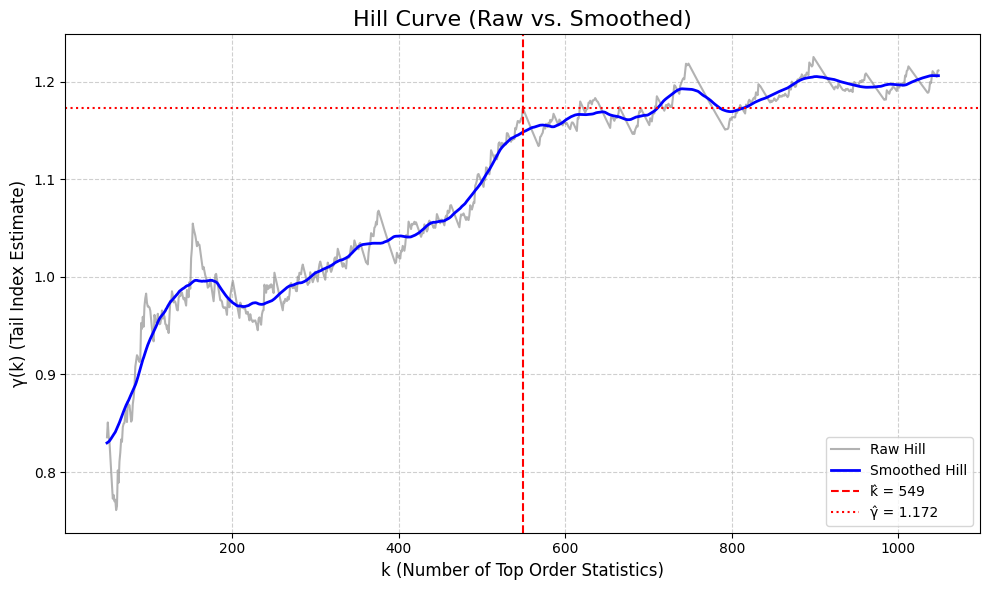

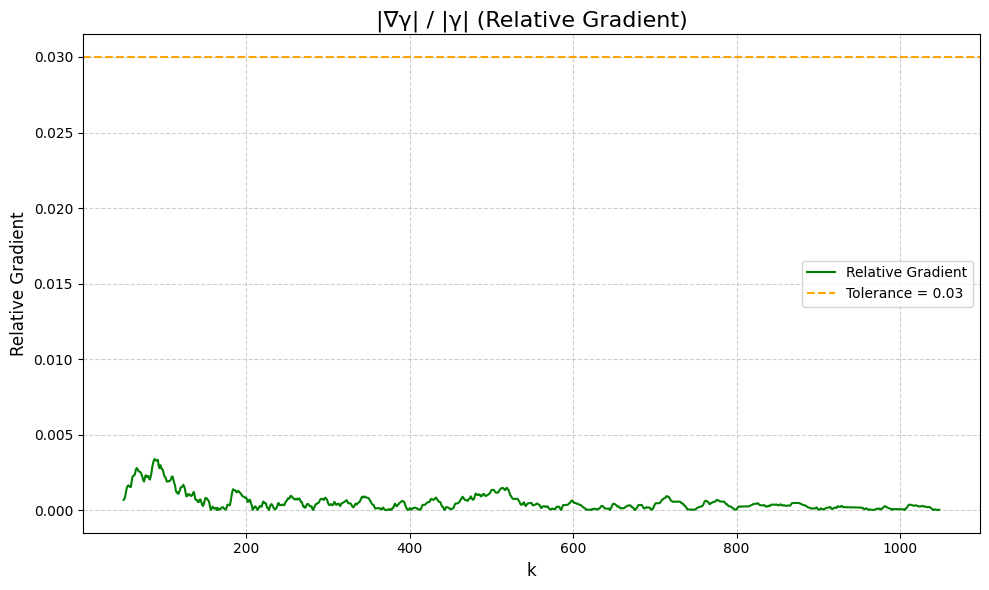

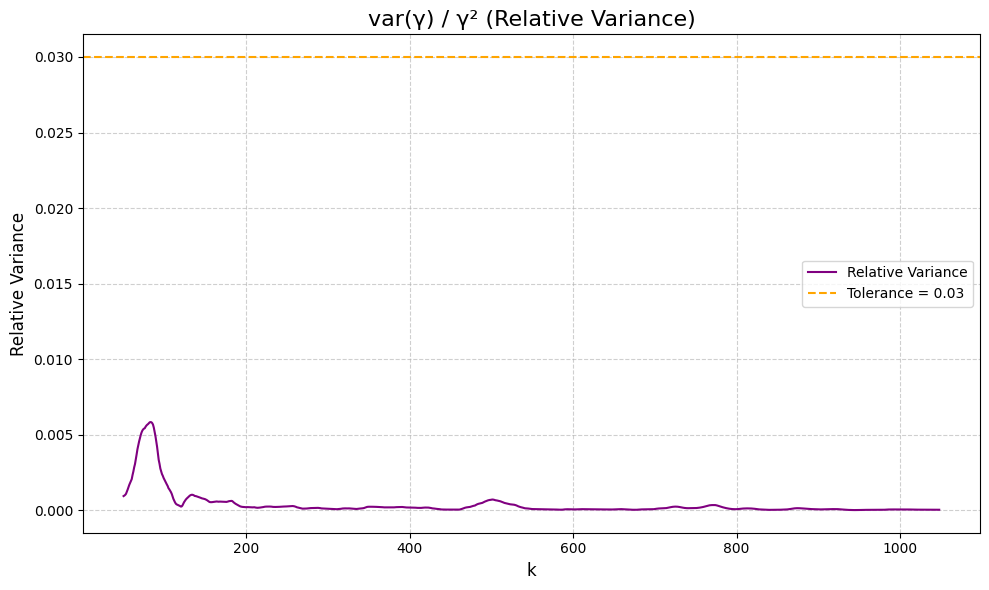

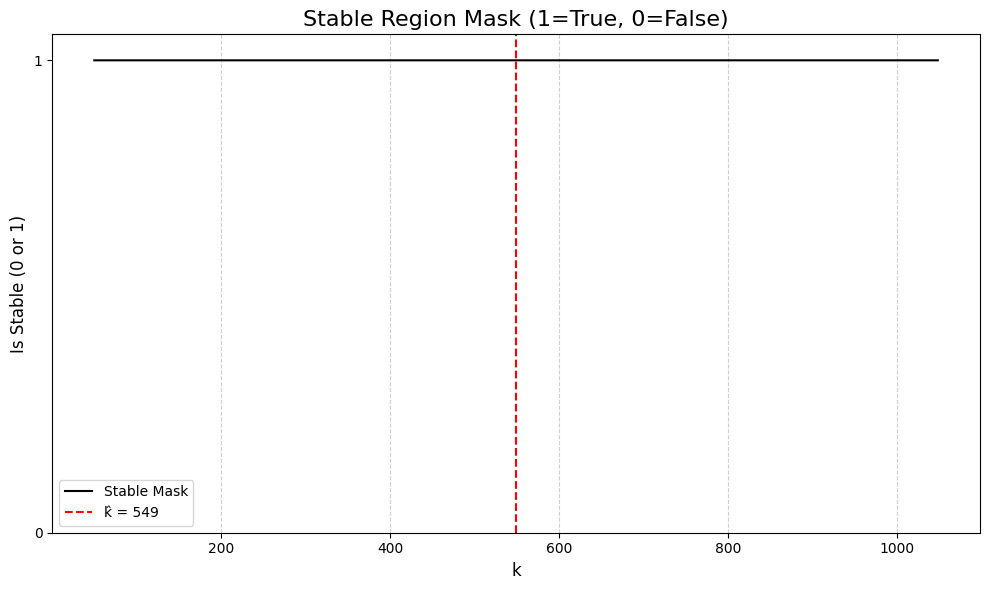


--- Results ---
Estimated Threshold (u_hat): 150.1000
Number of Exceedances (k_hat): 549
Estimated Tail Index (gamma_hat): 1.1725
----------------


In [92]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [93]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.24% of data exceed threshold 150.10


In [94]:
# 1) k 위치의 진단치
idx = np.where(diag.k_grid == k_hat)[0][0]
print("grad@k =", diag.grad_norm[idx], "  var_rel@k =", diag.var_rel[idx])

# 2) KS 적합 진단 (선택된 k에서 GPD fit)
from scipy import stats
y = np.asarray(df_merged["Exceedance"], dtype=float)
y = y[np.isfinite(y)]
y_pos = np.sort(y)[::-1]
y_pos = y_pos[y_pos > 0]

excess = y_pos[:k_hat] - y_pos[k_hat]
excess = excess[excess > 0]

shape, loc, scale = stats.genpareto.fit(excess, floc=0.0)
D, p = stats.kstest(excess, cdf=stats.genpareto.cdf, args=(shape, loc, scale))
print("KS D, p =", D, p)  # p >= 0.05 정도면 무난

# 3) 민감도: k를 ±10% 바꿔도 gamma 거의 같은지
for delta in (-int(0.1*k_hat), int(0.1*k_hat)):
    k2 = np.clip(k_hat + delta, diag.k_grid[0], diag.k_grid[-1])
    g2 = np.mean(np.log(y_pos[:k2]) - np.log(y_pos[k2]))
    print(f"k={k2}, gamma={g2:.4f}")


grad@k = 0.0004766732358406748   var_rel@k = 8.918367894903275e-05
KS D, p = 0.03823124849822601 0.38884010189388085
k=495, gamma=1.1046
k=603, gamma=1.1555


In [95]:
# 1) 현재 k에서 GPD 적합된 모수 확인(힐 추정보다 직관적일 수 있음)
shape, loc, scale = stats.genpareto.fit(excess, floc=0.0)
print("GPD shape(xi) ≈", shape, "scale ≈", scale)

# 2) ±10% 정확히 움직였을 때의 감마 변화
for frac in (-0.1, +0.1):
    k2 = int(np.clip(k_hat * (1+frac), diag.k_grid[0], diag.k_grid[-1]))
    g2 = np.mean(np.log(y_pos[:k2]) - np.log(y_pos[k2]))
    print(f"k={k2}, gamma={g2:.4f}")


GPD shape(xi) ≈ 0.8177769887693866 scale ≈ 245.92364654345226
k=494, gamma=1.0987
k=603, gamma=1.1555


#ADF

In [26]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['10_2', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Government spending', '6. National security', '8. Regulation', '10. Sovereign debt, currency crises', 'Exceedance']
Non-stationary variables to be differenced: ['House Price Index', 'CPI', 'Unemployment Rate', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '5. Health care', '7. Entitlement programs', 'Financial Regulation', '9. Trade policy', 'cpu_index']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2', 'House Price Index_diff', 'CPI_diff', 'Unemployment Rate_diff', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '4. Govern

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
                          Causal_Var  Most_Recent_Lag
0     1. Economic Policy Uncertainty                1
1                           3. Taxes                1
2       7. Entitlement programs_diff                1
3                      8. Regulation                1
4  Fiscal Policy (Taxes OR Spending)                1
5         Three_Component_Index_diff                1
6             Unemployment Rate_diff                1
7             House Price Index_diff                2


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul

#Trainning

In [31]:
#M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {
        '1. Economic Policy Uncertainty': [1],
        '3. Taxes': [1],
        '7. Entitlement programs_diff': [1],
        '8. Regulation': [1],
        'Fiscal Policy (Taxes OR Spending)': [1],
        'Unemployment Rate_diff': [1],
        'Three_Component_Index_diff': [1],
        'House Price Index_diff': [2],
    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
        'Category_Business Disruption and System Failures',
        'Category_Clients, Products & Business Practices',
        'Category_Damage to Physical Assets',
        'Category_Employment Practices and Workplace Safety',
        'Category_Execution, Delivery & Process Management',
        'Category_External Fraud', 'Category_Internal Fraud',
        'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
        'Category_Banking', 'Category_Brokerage & Advisory',
        'Category_Insurance', 'Category_Investment Banking',
        'Category_Markets & Treasury', 'Category_Others'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {
        '1. Economic Policy Uncertainty': [1],
        '3. Taxes': [1],
        '7. Entitlement programs_diff': [1],
        '8. Regulation': [1],
        'Fiscal Policy (Taxes OR Spending)': [1],
        'Unemployment Rate_diff': [1],
        'Three_Component_Index_diff': [1],
        'House Price Index_diff': [2],
    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
        'Category_Business Disruption and System Failures',
        'Category_Clients, Products & Business Practices',
        'Category_Damage to Physical Assets',
        'Category_Employment Practices and Workplace Safety',
        'Category_Execution, Delivery & Process Management',
        'Category_External Fraud', 'Category_Internal Fraud',
        'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
        'Category_Banking', 'Category_Brokerage & Advisory',
        'Category_Insurance', 'Category_Investment Banking',
        'Category_Markets & Treasury', 'Category_Others'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")

,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



SyntaxError: invalid syntax (ipython-input-2794779870.py, line 58)

In [ ]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -4071.23
  단일 GP 로그우도: -4489.76
  LRT statistic = 837.07 (df = 10)
  p‑value = 2.205e-173 -> reject single GP model
  AIC (GP 트리) = 8166.46, AIC (단일 GP) = 8983.53


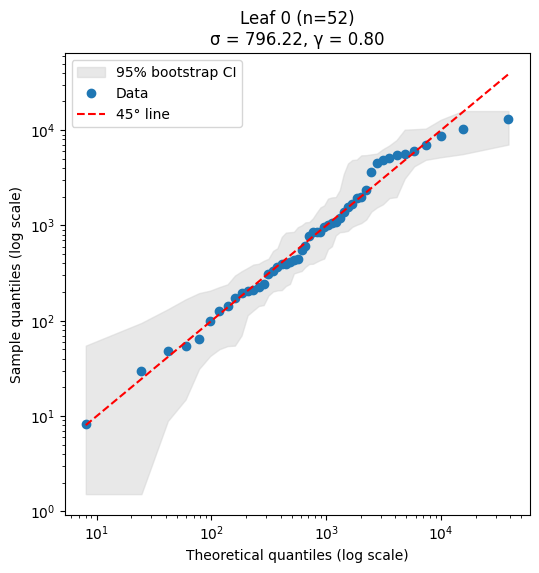

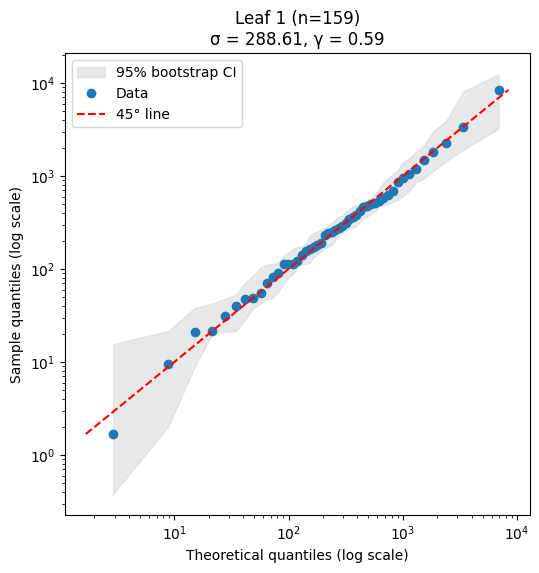

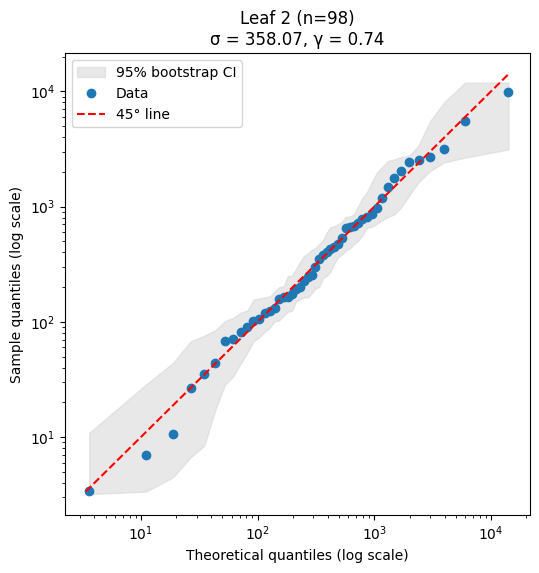

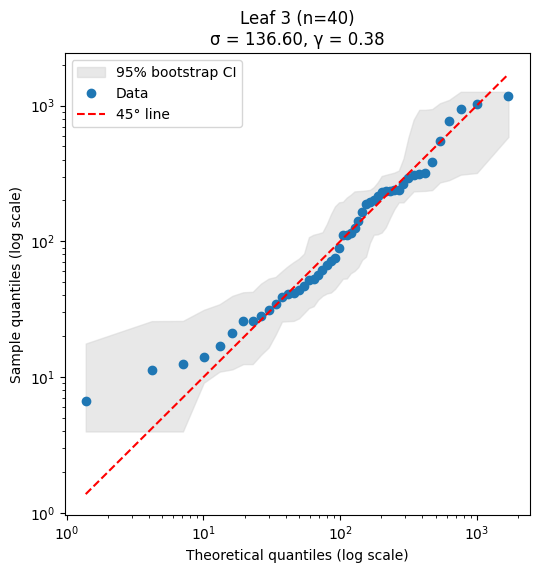

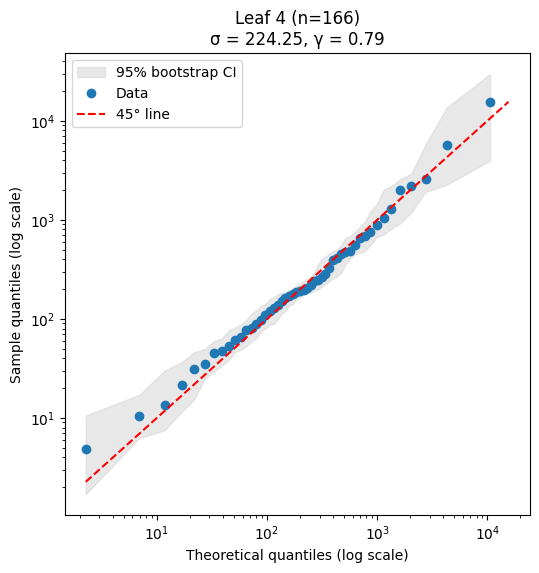

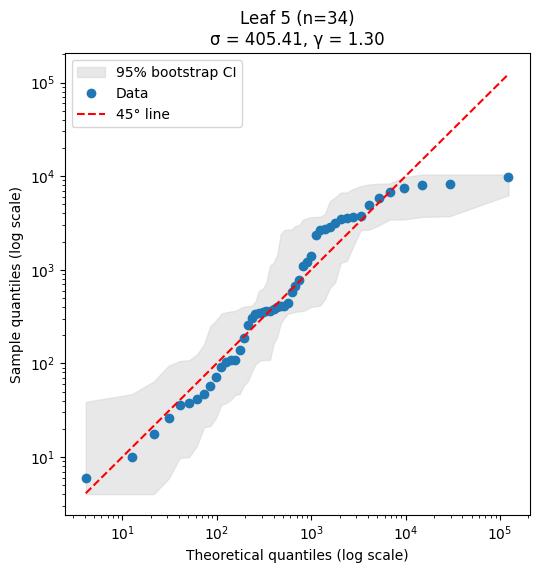

In [ ]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [ ]:
importance=pd.DataFrame(importances)
importance.head()

,name,importance
0,8. Regulation_lag1,0.023514
1,1. Economic Policy Uncertainty_lag1,0.012282
2,3. Taxes_lag1,0.000000
3,7. Entitlement programs_diff_lag1,0.000000
4,Fiscal Policy (Taxes OR Spending)_lag1,0.000000


In [ ]:
# === 프루닝 직후에 추가 ===
import numpy as np
import l1_l2_gpd_patched_new_catprune as M  # 이미 위에서 import 했다면 생략

# 모듈 헬퍼 준비
find_leaf = M.find_leaf
get_leaves = M._get_all_leaves

def _get_leaf_params(leaf):
    gp = getattr(leaf, "gpd_params", None)
    return (np.nan, np.nan) if gp is None else (float(gp[0]), float(gp[1]))

# CI 계산
cis = M.leaf_confidence_intervals(
    gpd_tail_tree_pruned, X_tail, y_tail,
    find_leaf=find_leaf, get_leaves=get_leaves, get_leaf_params=_get_leaf_params
)

# 보기 좋게 출력 (+ 리프별 샘플 수)
leaf_objs = np.array([find_leaf(gpd_tail_tree_pruned, X_tail[i]) for i in range(len(X_tail))], dtype=object)
leaves = get_leaves(gpd_tail_tree_pruned)

print("\n===== Leaf-wise γ 95% CI =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    lo, hi = (rec.get("ci_95", [np.nan, np.nan]) + [np.nan, np.nan])[:2]
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI =====
Leaf#00  N=  52   γ= 0.801   CI95=[ 0.264,  1.337]
Leaf#01  N= 159   γ= 0.589   CI95=[ 0.353,  0.824]
Leaf#02  N=  98   γ= 0.739   CI95=[ 0.383,  1.095]
Leaf#03  N=  40   γ= 0.379   CI95=[-0.071,  0.828]
Leaf#04  N= 166   γ= 0.792   CI95=[ 0.535,  1.049]
Leaf#05  N=  34   γ= 1.298   CI95=[ 0.401,  2.195]


In [ ]:
import numpy as np
import scipy.stats as st

def hill_ci(gamma_hat, n_exceed, alpha=0.05):
    """Asymptotic normal CI for Hill estimator"""
    se = gamma_hat / np.sqrt(n_exceed)
    z = st.norm.ppf(1 - alpha/2)
    return gamma_hat - z*se, gamma_hat + z*se

print("\n===== Leaf-wise γ 95% CI (Asymptotic) =====")
for i, rec in enumerate(cis):
    gamma = rec.get("gamma", np.nan)
    n_i = int(np.sum(leaf_objs == leaves[i])) if i < len(leaves) else 0
    if np.isnan(gamma) or n_i < 30:  # 샘플 적으면 skip
        lo, hi = np.nan, np.nan
    else:
        lo, hi = hill_ci(gamma, n_i, alpha=0.05)
    print(f"Leaf#{i:02d}  N={n_i:4d}   γ={gamma: .3f}   CI95=[{lo: .3f}, {hi: .3f}]")



===== Leaf-wise γ 95% CI (Asymptotic) =====
Leaf#00  N=  52   γ= 0.801   CI95=[ 0.583,  1.018]
Leaf#01  N= 159   γ= 0.589   CI95=[ 0.497,  0.680]
Leaf#02  N=  98   γ= 0.739   CI95=[ 0.593,  0.885]
Leaf#03  N=  40   γ= 0.379   CI95=[ 0.261,  0.496]
Leaf#04  N= 166   γ= 0.792   CI95=[ 0.672,  0.913]
Leaf#05  N=  34   γ= 1.298   CI95=[ 0.862,  1.735]


In [ ]:
! pip install pygam

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 2.7 MB/s eta 0:00:00



--- Raw GPD-CART Structure ---
[8. Regulation_lag1 ≤ 51.78] (PenalizedGain=11.233) N=549
  Leaf: N=52, GPD(σ=796.193, γ=0.801), NLL=441.0
  [1. Economic Policy Uncertainty_lag1 ≤ 134.1] (PenalizedGain=5.214) N=497
    [8. Regulation_lag1 ≤ 87.06] (PenalizedGain=3.960) N=463
      [8. Regulation_lag1 ≤ 66.68] (PenalizedGain=1.481) N=257
        Leaf: N=159, GPD(σ=288.619, γ=0.589), NLL=1153.4
        Leaf: N=98, GPD(σ=358.068, γ=0.739), NLL=746.7
      [1. Economic Policy Uncertainty_lag1 ≤ 109.9] (PenalizedGain=4.543) N=206
        Leaf: N=40, GPD(σ=136.596, γ=0.379), NLL=251.8
        Leaf: N=166, GPD(σ=224.249, γ=0.792), NLL=1196.0
    Leaf: N=34, GPD(σ=405.407, γ=1.298), NLL=282.3

--- Pruned GPD-CART Structure ---
[8. Regulation_lag1 ≤ 51.78] (PenalizedGain=11.233) N=549
  Leaf: N=52, GPD(σ=796.193, γ=0.801), NLL=441.0
  [1. Economic Policy Uncertainty_lag1 ≤ 134.1] (PenalizedGain=5.214) N=497
    [8. Regulation_lag1 ≤ 87.06] (PenalizedGain=3.960) N=463
      [8. Regulation_lag1 ≤

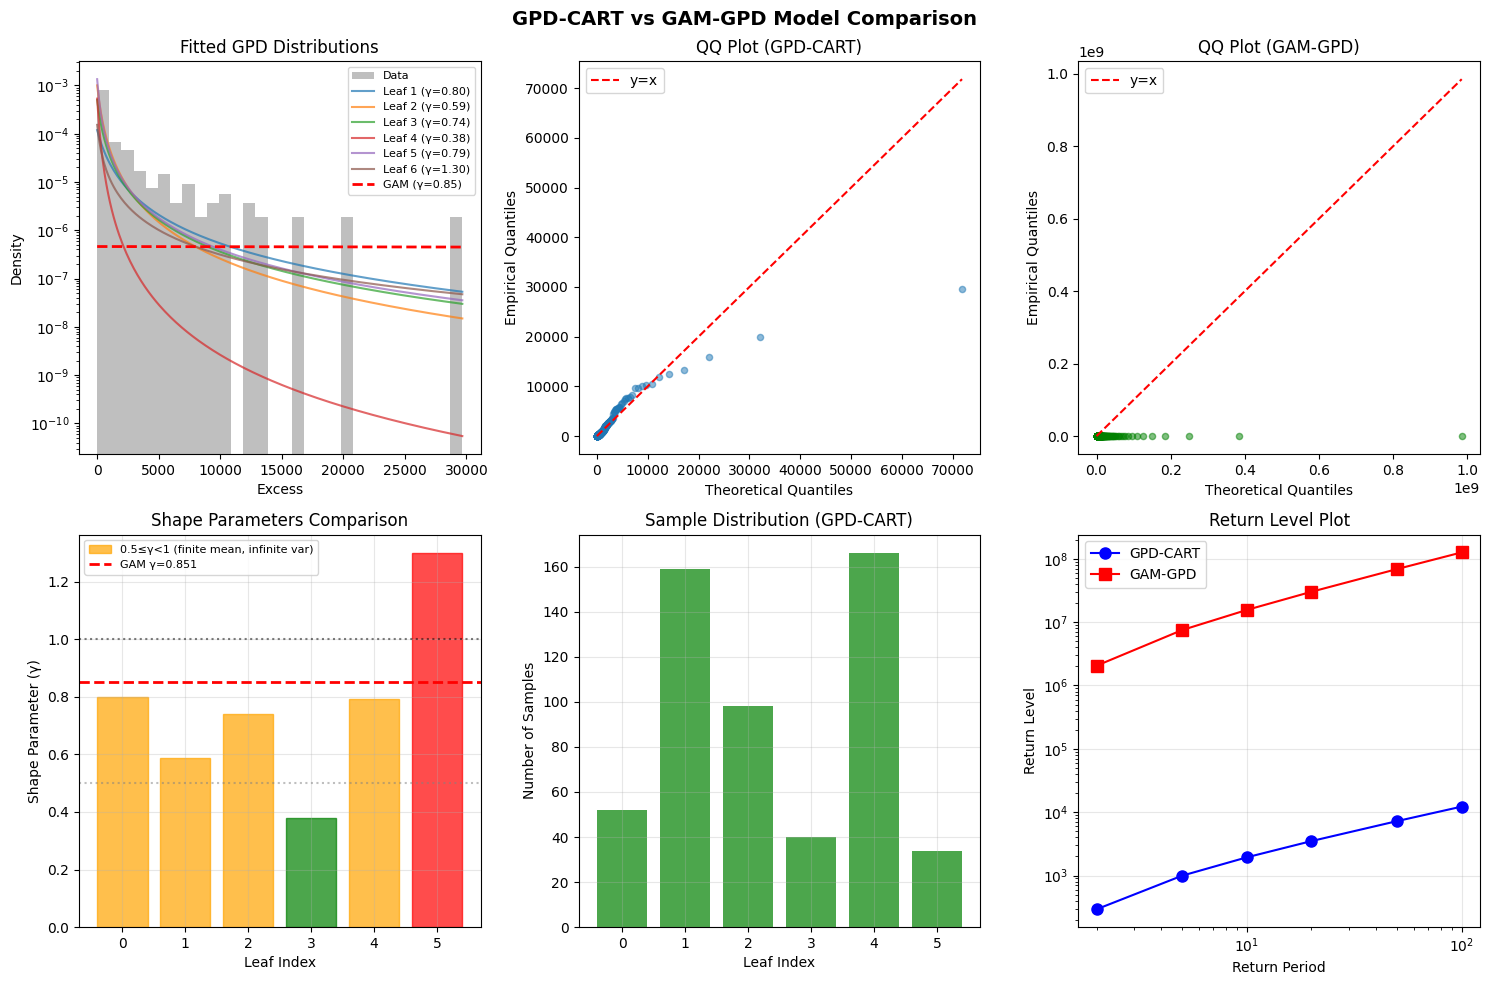

In [ ]:
"""
Complete GPD-CART vs GAM-GPD Comparison Analysis
Based on your operational risk data and Farkas et al. (2021) methodology

This script extends your existing analysis to include:
1. GPD-CART (already implemented in your code)
2. GAM-GPD comparison
3. Model performance metrics
4. Visualization and diagnostics
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from sklearn.model_selection import KFold
import logging
import warnings
warnings.filterwarnings('ignore')

# Import your module
import l1_l2_gpd_patched_new_catprune as M

# Try to import GAM libraries
try:
    from pygam import GAM, s, f, te
    PYGAM_AVAILABLE = True
except ImportError:
    PYGAM_AVAILABLE = False
    print("Warning: pygam not installed. Using simplified GAM approach.")

# Patch gpd_nll to handle array sigma
def patched_gpd_nll(y: np.ndarray, sigma: Union[float, np.ndarray], gamma: float) -> float:
    """
    Vectorized GPD negative log-likelihood supporting per-observation sigma.
    """
    y = np.asarray(y, dtype=float)
    sigma = np.asarray(sigma)
    if sigma.ndim == 0:
        sigma = np.full_like(y, float(sigma))
    if len(sigma) != len(y):
        raise ValueError("sigma must be scalar or same length as y")
    if np.any(sigma <= 0):
        return np.inf
    if not np.isfinite(gamma):
        return np.inf

    z = 1.0 + gamma * (y / sigma)
    if np.any(z <= 0):
        return np.inf

    n = y.size
    if abs(gamma) < 1e-12:
        # Exponential case
        return np.sum(np.log(sigma) + y / sigma)

    return np.sum(np.log(sigma)) + (1.0 + 1.0 / gamma) * np.sum(np.log(z))

# Monkey patch the module
M.gpd_nll = patched_gpd_nll

# ============================================================================
# GAM-GPD Implementation (Chavez-Demoulin et al. 2015 approach)
# ============================================================================

class GAM_GPD:
    """
    GAM-GPD model following Chavez-Demoulin et al. (2015)
    Simplified implementation for comparison with GPD-CART
    """

    def __init__(self, n_splines=10):
        self.n_splines = n_splines
        self.sigma_model = None
        self.gamma_const = None
        self.pca = None
        self.sigma_smooth = None
        self.fitted = False

    def fit(self, X, y, feature_names=None):
        """
        Fit GAM-GPD model

        Parameters:
        -----------
        X : array-like
            Features
        y : array-like
            Excesses (already above threshold)
        """
        if not PYGAM_AVAILABLE:
            # Fallback to simple approach
            return self._fit_simple(X, y)

        print("\nFitting GAM-GPD with smooth functions...")

        # Step 1: Initial GPD fit for starting values
        init_params = M.fit_gpd_mle(y)
        init_sigma, init_gamma = init_params[0], init_params[1]

        # Step 2: Fit GAM for log(sigma) using profile likelihood approach
        # We use a proxy based on sample variance in windows
        n_samples = len(y)
        n_windows = min(20, n_samples // 10)

        # Create local variance estimates
        window_stats = []
        for i in range(n_windows):
            start_idx = i * n_samples // n_windows
            end_idx = (i + 1) * n_samples // n_windows
            window_y = y[start_idx:end_idx]
            if len(window_y) > 2:
                local_var = np.var(window_y)
                local_mean_x = np.mean(X[start_idx:end_idx], axis=0)
                window_stats.append({
                    'log_var': np.log(max(local_var, 1e-6)),
                    'x_mean': local_mean_x
                })

        if len(window_stats) > 3:
            # Fit GAM for log(sigma)
            X_windows = np.array([ws['x_mean'] for ws in window_stats])
            y_log_var = np.array([ws['log_var'] for ws in window_stats])

            # Use first few principal features
            from sklearn.decomposition import PCA
            self.pca = PCA(n_components=min(3, X.shape[1]))
            X_pca = self.pca.fit_transform(X)
            X_windows_pca = self.pca.transform(X_windows)

            # Fit GAM on principal components
            formula = s(0, n_splines=self.n_splines)
            if X_pca.shape[1] > 1:
                formula += s(1, n_splines=self.n_splines)

            self.sigma_model = GAM(formula)
            self.sigma_model.fit(X_windows_pca[:, :2], y_log_var)

            # Predict sigma for training data
            log_var_train = self.sigma_model.predict(X_pca[:, :2])
            self.sigma_smooth = np.maximum(np.exp(log_var_train), 1e-6)
        else:
            self.sigma_smooth = np.full(n_samples, init_sigma)

        # Step 3: Estimate gamma (simplified - could be smooth too)
        # For now, use constant gamma estimated via MLE
        self.gamma_const = init_gamma

        # Store results
        self.params = {
            'sigma_mean': np.mean(self.sigma_smooth),
            'sigma_std': np.std(self.sigma_smooth),
            'gamma': self.gamma_const,
            'init_sigma': init_sigma,
            'init_gamma': init_gamma
        }

        self.fitted = True
        print(f"GAM-GPD fitted: σ_mean={self.params['sigma_mean']:.3e}, "
              f"σ_std={self.params['sigma_std']:.3e}, γ={self.params['gamma']:.3f}")

        return self

def _fit_gam_profile_likelihood(self, X, y):
    """Profile likelihood approach for GAM-GPD"""

    # Step 1: 초기 GPD 파라미터 추정
    init_params = M.fit_gpd_mle(y)
    init_sigma, init_gamma = init_params[0], init_params[1]

    # Step 2: 각 관측값에 대한 local scale 추정을 위한 sliding window
    n_samples = len(y)
    window_size = max(20, n_samples // 10)

    local_sigmas = []
    local_X = []

    for i in range(0, n_samples, window_size//2):
        end_idx = min(i + window_size, n_samples)
        if end_idx - i < 10:
            continue

        y_window = y[i:end_idx]
        X_window = X[i:end_idx]

        # 각 window에서 GPD MLE 추정
        try:
            local_params = M.fit_gpd_mle(y_window)
            local_sigmas.append(np.log(local_params[0]))  # log-scale for GAM
            local_X.append(np.mean(X_window, axis=0))
        except:
            continue

    # Step 3: GAM fitting on log(sigma)
    if len(local_sigmas) > 5:
        # PCA for dimension reduction
        pca = PCA(n_components=min(3, X.shape[1]))
        X_pca = pca.fit_transform(np.array(local_X))

        # Fit GAM
        gam = GAM(s(0) + s(1) + s(2))
        gam.fit(X_pca, np.array(local_sigmas))

        # Predict for all data
        X_all_pca = pca.transform(X)
        log_sigma_pred = gam.predict(X_all_pca)
        self.sigma_smooth = np.exp(log_sigma_pred)
        self.gam_model = gam
        self.pca = pca
    else:
        self.sigma_smooth = np.full(n_samples, init_sigma)

    # Step 4: Profile likelihood에서 gamma 추정
    def profile_nll(gamma):
        return M.gpd_nll(y, self.sigma_smooth, gamma)

    result = minimize(profile_nll, init_gamma, method='L-BFGS-B',
                     bounds=[(-0.5, 2.0)])
    self.gamma_const = result.x[0]

#ret_levels_cart


    def compute_nll(self, X, y):
        """Compute negative log-likelihood on new data"""
        if not self.fitted:
            raise ValueError("Model not fitted yet")

        if hasattr(self, 'regions'):
            # Simple regional model
            X_pc1 = self.pca.transform(X).ravel()
            total_nll = 0.0
            for region in self.regions:
                if region['name'] == 'low':
                    mask = X_pc1 <= self.q33
                elif region['name'] == 'mid':
                    mask = (X_pc1 > self.q33) & (X_pc1 <= self.q67)
                else:
                    mask = X_pc1 > self.q67
                if mask.sum() > 0:
                    y_region = y[mask]
                    nll = M.gpd_nll(y_region, region['sigma'], region['gamma'])
                    total_nll += nll
            return total_nll
        else:
            # Smooth model
            if self.sigma_model is None:
                return M.gpd_nll(y, self.params['sigma_mean'], self.params['gamma'])
            X_pca = self.pca.transform(X)
            log_var_pred = self.sigma_model.predict(X_pca[:, :2])
            sigma_pred = np.maximum(np.exp(log_var_pred), 1e-6)
            return M.gpd_nll(y, sigma_pred, self.gamma_const)

# ============================================================================
# Model Comparison Functions
# ============================================================================

def compare_gpd_gam(gpd_tree, gam_model, X_tail, y_tail, feature_names):
    """
    Compare GPD-CART and GAM-GPD models

    Returns detailed comparison metrics
    """
    print("\n" + "="*70)
    print("MODEL COMPARISON: GPD-CART vs GAM-GPD")
    print("="*70)

    # 1. Compute NLL for GPD-CART
    nll_cart = M.get_subtree_nll(gpd_tree, X_tail, y_tail)
    leaves = M._get_all_leaves(gpd_tree)
    n_params_cart = 2 * len(leaves)  # sigma and gamma for each leaf
    aic_cart = 2 * nll_cart + 2 * n_params_cart
    bic_cart = 2 * nll_cart + n_params_cart * np.log(len(y_tail))

    # 2. Compute NLL for GAM-GPD
    nll_gam = gam_model.compute_nll(X_tail, y_tail)
    # Approximate degrees of freedom for GAM
    if hasattr(gam_model, 'regions'):
        n_params_gam = 2 * len(gam_model.regions)
    else:
        n_params_gam = gam_model.n_splines * 2 if PYGAM_AVAILABLE else 10  # Approximate
    aic_gam = 2 * nll_gam + 2 * n_params_gam
    bic_gam = 2 * nll_gam + n_params_gam * np.log(len(y_tail))

    # 3. Extract GPD-CART parameters
    cart_params = []
    for i, leaf in enumerate(leaves):
        if leaf.gpd_params is not None:
            cart_params.append({
                'leaf_id': i,
                'sigma': leaf.gpd_params[0],
                'gamma': leaf.gpd_params[1],
                'n_samples': leaf.n_samples
            })

    # 4. Create comparison table
    comparison_results = pd.DataFrame({
        'Model': ['GPD-CART', 'GAM-GPD'],
        'NLL': [nll_cart, nll_gam],
        'AIC': [aic_cart, aic_gam],
        'BIC': [bic_cart, bic_gam],
        'Parameters': [n_params_cart, n_params_gam]
    })

    print("\nModel Performance Metrics:")
    print(comparison_results.to_string(index=False))

    # 5. Parameter comparison
    print("\n" + "-"*50)
    print("GPD-CART Leaf Parameters:")
    cart_df = pd.DataFrame(cart_params)
    if not cart_df.empty:
        print(cart_df.to_string(index=False))

        # Check for infinite mean (gamma >= 1)
        high_risk_leaves = cart_df[cart_df['gamma'] >= 1.0]
        if not high_risk_leaves.empty:
            print("\n⚠️  WARNING: Leaves with γ ≥ 1 (infinite mean):")
            print(high_risk_leaves[['leaf_id', 'gamma', 'n_samples']].to_string(index=False))

    print("\n" + "-"*50)
    print("GAM-GPD Parameters:")
    print(f"  σ_mean: {gam_model.params['sigma_mean']:.3e}")
    print(f"  σ_std:  {gam_model.params['sigma_std']:.3e}")
    print(f"  γ:      {gam_model.params['gamma']:.3f}")

    if gam_model.params['gamma'] >= 1.0:
        print("  ⚠️  WARNING: γ ≥ 1 (infinite mean)")

    # 6. Likelihood ratio test
    lr_statistic = 2 * (nll_gam - nll_cart)
    df_diff = abs(n_params_cart - n_params_gam)
    if df_diff > 0:
        p_value = 1 - stats.chi2.cdf(abs(lr_statistic), df_diff)
        print("\n" + "-"*50)
        print("Likelihood Ratio Test:")
        print(f"  LR statistic: {lr_statistic:.3f}")
        print(f"  Degrees of freedom: {df_diff}")
        print(f"  p-value: {p_value:.4f}")

        if p_value < 0.05:
            if lr_statistic > 0:
                print(f"  Result: GPD-CART significantly better (p < 0.05)")
            else:
                print(f"  Result: GAM-GPD significantly better (p < 0.05)")
        else:
            print(f"  Result: No significant difference")

    return comparison_results, cart_params

def cross_validate_models_proper(X_all, y_all, feature_names, threshold_quantile=0.95, n_folds=5):
    """Proper cross-validation without data leakage"""

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    cv_results = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(X_all), 1):
        X_train, X_test = X_all[train_idx], X_all[test_idx]
        y_train, y_test = y_all[train_idx], y_all[test_idx]

        # 각 fold에서 독립적으로 threshold 계산
        u_train = np.quantile(y_train, threshold_quantile)

        # Training tail data
        train_tail_mask = y_train > u_train
        if train_tail_mask.sum() < 20:
            continue

        X_train_tail = X_train[train_tail_mask]
        y_train_tail = y_train[train_tail_mask] - u_train

        # Test tail data (같은 threshold 사용)
        test_tail_mask = y_test > u_train
        if test_tail_mask.sum() < 5:
            continue

        X_test_tail = X_test[test_tail_mask]
        y_test_tail = y_test[test_tail_mask] - u_train

        # 모델 훈련 및 평가...
        # Fit GPD-CART
        min_leaf = max(20, int(0.05 * len(y_train)))
        gpd_tree = M.grow_tree_gpd(
            X_train, y_train, feature_names,
            min_leaf=min_leaf, max_depth=3
        )

        # Prune if enough data
        if len(y_train) > 100:
            gpd_tree = M.prune_gpd_single_alpha(gpd_tree, 0.01)

        # Fit GAM-GPD
        gam_model = GAM_GPD()
        gam_model.fit(X_train, y_train, feature_names)

        # Evaluate on test set
        nll_cart_test = M.get_subtree_nll(gpd_tree, X_test, y_test)
        nll_gam_test = gam_model.compute_nll(X_test, y_test)

        # Get statistics
        leaves = M._get_all_leaves(gpd_tree)
        gammas = [l.gpd_params[1] for l in leaves if l.gpd_params is not None]

        fold_results = {
            'fold': fold,
            'n_train': len(y_train),
            'n_test': len(y_test),
            'cart_nll': nll_cart_test,
            'gam_nll': nll_gam_test,
            'cart_leaves': len(leaves),
            'cart_mean_gamma': np.mean(gammas) if gammas else np.nan,
            'gam_gamma': gam_model.params['gamma']
        }

        cv_results.append(fold_results)

        print(f"  CART: NLL={nll_cart_test:.1f}, Leaves={len(leaves)}, γ_mean={fold_results['cart_mean_gamma']:.3f}")
        print(f"  GAM:  NLL={nll_gam_test:.1f}, γ={gam_model.params['gamma']:.3f}")

    # Summarize results
    cv_df = pd.DataFrame(cv_results)

    print("\n" + "="*70)
    print("CROSS-VALIDATION SUMMARY")
    print("="*70)

    print("\nDetailed Results:")
    print(cv_df[['fold', 'cart_nll', 'gam_nll', 'cart_leaves', 'cart_mean_gamma']].to_string(index=False))

    print("\n" + "-"*50)
    print("Average Performance:")
    print(f"GPD-CART:")
    print(f"  Mean NLL: {cv_df['cart_nll'].mean():.1f} ± {cv_df['cart_nll'].std():.1f}")
    print(f"  Mean leaves: {cv_df['cart_leaves'].mean():.1f}")
    print(f"  Mean γ: {cv_df['cart_mean_gamma'].mean():.3f}")

    print(f"\nGAM-GPD:")
    print(f"  Mean NLL: {cv_df['gam_nll'].mean():.1f} ± {cv_df['gam_nll'].std():.1f}")
    print(f"  Mean γ: {cv_df['gam_gamma'].mean():.3f}")

    # Statistical test
    if len(cv_df) >= 3:
        from scipy.stats import ttest_rel
        t_stat, p_value = ttest_rel(cv_df['cart_nll'], cv_df['gam_nll'])
        print("\n" + "-"*50)
        print("Paired t-test (H0: equal performance):")
        print(f"  t-statistic: {t_stat:.3f}")
        print(f"  p-value: {p_value:.4f}")

        if p_value < 0.05:
            if t_stat < 0:
                print("  ✓ GPD-CART significantly better (p < 0.05)")
            else:
                print("  ✓ GAM-GPD significantly better (p < 0.05)")
        else:
            print("  No significant difference")

    return cv_df

def visualize_comparison(gpd_tree, gam_model, X_tail, y_tail, cart_params):
    """
    Create comprehensive visualization comparing models
    """
    fig = plt.figure(figsize=(15, 10))

    # 1. Exceedance distribution with fits
    ax1 = plt.subplot(2, 3, 1)
    ax1.hist(y_tail, bins=30, density=True, alpha=0.5, color='gray', label='Data')

    # Add GPD fits from CART
    x_range = np.linspace(0, np.max(y_tail), 200)
    for i, params in enumerate(cart_params):
        sigma, gamma = params['sigma'], params['gamma']
        # GPD PDF
        if gamma != 0:
            pdf = (1/sigma) * (1 + gamma * x_range/sigma)**(-1/gamma - 1)
        else:
            pdf = (1/sigma) * np.exp(-x_range/sigma)
        pdf[pdf < 0] = 0

        weight = params['n_samples'] / len(y_tail)
        ax1.plot(x_range, weight * pdf, alpha=0.7, label=f'Leaf {i+1} (γ={gamma:.2f})')

    # Add GAM fit
    sigma_gam = gam_model.params['sigma_mean']
    gamma_gam = gam_model.params['gamma']
    if gamma_gam != 0:
        pdf_gam = (1/sigma_gam) * (1 + gamma_gam * x_range/sigma_gam)**(-1/gamma_gam - 1)
    else:
        pdf_gam = (1/sigma_gam) * np.exp(-x_range/sigma_gam)
    pdf_gam[pdf_gam < 0] = 0
    ax1.plot(x_range, pdf_gam, 'r--', linewidth=2, label=f'GAM (γ={gamma_gam:.2f})')

    ax1.set_xlabel('Excess')
    ax1.set_ylabel('Density')
    ax1.set_title('Fitted GPD Distributions')
    ax1.legend(fontsize=8)
    ax1.set_yscale('log')

    # 2. QQ Plot for GPD-CART
    ax2 = plt.subplot(2, 3, 2)

    # Use weighted average parameters for QQ plot
    weights = np.array([p['n_samples'] for p in cart_params])
    weights = weights / weights.sum()
    avg_sigma = sum(p['sigma'] * w for p, w in zip(cart_params, weights))
    avg_gamma = sum(p['gamma'] * w for p, w in zip(cart_params, weights))

    n = len(y_tail)
    emp_quantiles = np.sort(y_tail)
    probs = (np.arange(1, n+1) - 0.5) / n

    if avg_gamma != 0:
        theo_quantiles = avg_sigma * ((1-probs)**(-avg_gamma) - 1) / avg_gamma
    else:
        theo_quantiles = -avg_sigma * np.log(1-probs)

    ax2.scatter(theo_quantiles, emp_quantiles, alpha=0.5, s=20)
    ax2.plot([0, max(theo_quantiles)], [0, max(theo_quantiles)], 'r--', label='y=x')
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Empirical Quantiles')
    ax2.set_title('QQ Plot (GPD-CART)')
    ax2.legend()

    # 3. QQ Plot for GAM-GPD
    ax3 = plt.subplot(2, 3, 3)

    if gamma_gam != 0:
        theo_quantiles_gam = sigma_gam * ((1-probs)**(-gamma_gam) - 1) / gamma_gam
    else:
        theo_quantiles_gam = -sigma_gam * np.log(1-probs)

    ax3.scatter(theo_quantiles_gam, emp_quantiles, alpha=0.5, s=20, color='green')
    ax3.plot([0, max(theo_quantiles_gam)], [0, max(theo_quantiles_gam)], 'r--', label='y=x')
    ax3.set_xlabel('Theoretical Quantiles')
    ax3.set_ylabel('Empirical Quantiles')
    ax3.set_title('QQ Plot (GAM-GPD)')
    ax3.legend()

    # 4. Shape parameter comparison
    ax4 = plt.subplot(2, 3, 4)

    leaf_gammas = [p['gamma'] for p in cart_params]
    leaf_sizes = [p['n_samples'] for p in cart_params]

    x_pos = np.arange(len(leaf_gammas))
    bars = ax4.bar(x_pos, leaf_gammas, alpha=0.7, color='blue')

    # Color bars by risk level
    for i, (bar, gamma) in enumerate(zip(bars, leaf_gammas)):
        if gamma >= 1.0:
            bar.set_color('red')
            bar.set_label('γ≥1 (infinite mean)' if i == 0 else "")
        elif gamma >= 0.5:
            bar.set_color('orange')
            bar.set_label('0.5≤γ<1 (finite mean, infinite var)' if i == 0 else "")
        else:
            bar.set_color('green')
            bar.set_label('γ<0.5 (finite variance)' if i == 0 else "")

    ax4.axhline(y=gamma_gam, color='red', linestyle='--', linewidth=2,
                label=f'GAM γ={gamma_gam:.3f}')
    ax4.axhline(y=1.0, color='black', linestyle=':', alpha=0.5)
    ax4.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

    ax4.set_xlabel('Leaf Index')
    ax4.set_ylabel('Shape Parameter (γ)')
    ax4.set_title('Shape Parameters Comparison')
    ax4.legend(fontsize=8)
    ax4.grid(True, alpha=0.3)

    # 5. Sample distribution
    ax5 = plt.subplot(2, 3, 5)
    ax5.bar(x_pos, leaf_sizes, alpha=0.7, color='green')
    ax5.set_xlabel('Leaf Index')
    ax5.set_ylabel('Number of Samples')
    ax5.set_title('Sample Distribution (GPD-CART)')
    ax5.grid(True, alpha=0.3)

    # 6. Return level plot
    ax6 = plt.subplot(2, 3, 6)

    return_periods = np.array([2, 5, 10, 20, 50, 100])
    probs_ret = 1 - 1/return_periods
    p_exceed = len(y_tail) / len(y_all_data)
    # CART return levels (using weighted average)
    if avg_gamma != 0:
        ret_levels_cart = avg_sigma * ((return_periods * p_exceed)**avg_gamma - 1) / avg_gamma
    else:
        ret_levels_cart = avg_sigma * np.log(return_periods * p_exceed)

    # GAM return levels
    if gamma_gam != 0:
        ret_levels_gam = sigma_gam * ((return_periods)**gamma_gam - 1) / gamma_gam
    else:
        ret_levels_gam = sigma_gam * np.log(return_periods)

    ax6.plot(return_periods, ret_levels_cart, 'bo-', label='GPD-CART', markersize=8)
    ax6.plot(return_periods, ret_levels_gam, 'rs-', label='GAM-GPD', markersize=8)

    ax6.set_xscale('log')
    ax6.set_yscale('log')
    ax6.set_xlabel('Return Period')
    ax6.set_ylabel('Return Level')
    ax6.set_title('Return Level Plot')
    ax6.legend()
    ax6.grid(True, alpha=0.3)

    plt.suptitle('GPD-CART vs GAM-GPD Model Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()

    return fig

# ============================================================================
# MAIN COMPARISON FUNCTION - Integrates with your existing code
# ============================================================================

def run_gpd_gam_comparison(gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list):
    """
    Main function to run GPD-CART vs GAM-GPD comparison
    This integrates with your existing analysis
    """

    print("\n" + "="*80)
    print("STARTING GPD-CART vs GAM-GPD COMPARISON")
    print("="*80)

    if gpd_tail_tree_pruned is None:
        print("ERROR: No GPD tree provided. Please run GPD-CART fitting first.")
        return None

    # 1. Fit GAM-GPD model
    print("\n" + "="*70)
    print("FITTING GAM-GPD MODEL")
    print("="*70)

    gam_model = GAM_GPD(n_splines=10)
    gam_model.fit(X_tail, y_tail, feature_names_list)

    # 2. Compare models
    comparison_results, cart_params = compare_gpd_gam(
        gpd_tail_tree_pruned, gam_model, X_tail, y_tail, feature_names_list
    )

    # 3. Cross-validation
    if len(y_tail) >= 100:
        cv_results = cross_validate_models(
            X_tail, y_tail, feature_names_list,
            n_folds=min(5, len(y_tail)//20)
        )
    else:
        print("\nSkipping cross-validation (insufficient data)")
        cv_results = None

    # 4. Visualization
    fig = visualize_comparison(
        gpd_tail_tree_pruned, gam_model, X_tail, y_tail, cart_params
    )

    # 5. Risk assessment
    print("\n" + "="*70)
    print("RISK ASSESSMENT SUMMARY")
    print("="*70)

    # CART risk assessment
    high_risk_cart = sum(1 for p in cart_params if p['gamma'] >= 1.0)
    samples_high_risk = sum(p['n_samples'] for p in cart_params if p['gamma'] >= 1.0)

    print(f"\nGPD-CART Risk Profile:")
    print(f"  Leaves with γ≥1 (infinite mean): {high_risk_cart}/{len(cart_params)}")
    print(f"  Samples in high-risk leaves: {samples_high_risk}/{len(y_tail)} "
          f"({100*samples_high_risk/len(y_tail):.1f}%)")

    print(f"\nGAM-GPD Risk Profile:")
    print(f"  Overall γ: {gam_model.params['gamma']:.3f}")
    if gam_model.params['gamma'] >= 1.0:
        print(f"  ⚠️  WARNING: Entire tail has infinite mean")
    elif gam_model.params['gamma'] >= 0.5:
        print(f"  ⚠️  WARNING: Finite mean but infinite variance")
    else:
        print(f"  ✓ Both mean and variance are finite")

    # 6. Save results
    results = {
        'gpd_tree': gpd_tail_tree_pruned,
        'gam_model': gam_model,
        'comparison': comparison_results,
        'cv_results': cv_results,
        'cart_params': cart_params,
        'figure': fig
    }

    return results

# ============================================================================
# EXECUTE COMPARISON - Add this to your main script
# ============================================================================

if __name__ == "__main__":
    # --- 1. 기본 설정 및 데이터 로딩 (기존 코드와 동일) ---


    # 데이터 준비 (기존 코드와 동일)
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {
        '1. Economic Policy Uncertainty': [1],
        '3. Taxes': [1],
        '7. Entitlement programs_diff': [1],
        '8. Regulation': [1],
        'Fiscal Policy (Taxes OR Spending)': [1],
        'M1_diff': [1],
        'Unemployment Rate_diff': [1],
        'Three_Component_Index_diff': [1],
        'House Price Index_diff': [2],
    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
        'Category_Business Disruption and System Failures',
        'Category_Clients, Products & Business Practices',
        'Category_Damage to Physical Assets',
        'Category_Employment Practices and Workplace Safety',
        'Category_Execution, Delivery & Process Management',
        'Category_External Fraud', 'Category_Internal Fraud',
        'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
        'Category_Banking', 'Category_Brokerage & Advisory',
        'Category_Insurance', 'Category_Investment Banking',
        'Category_Markets & Treasury', 'Category_Others'
    ]

    df_model_ready, feature_names_list = M.create_lagged_features(
        df=df_merged,
        target_col=TARGET_VARIABLE,
        lag_config=selected_lags_dict,
        date_col=DATE_COLUMN,
        start_year=START_YEAR,
        additional_features=categorical_cols_list
    )

    X_all_data = df_model_ready[feature_names_list].to_numpy(dtype=float)
    y_all_data = df_model_ready[TARGET_VARIABLE].to_numpy(dtype=float)

    # 임계값을 이용해 tail 데이터 분리
    u_threshold = u_hat
    mask_tail = y_all_data > u_threshold
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # Excesses for GPD

    logging.info(f"Threshold u = {u_threshold:.2f}, Tail data size = {len(y_tail)}")

    # --- 2. GPD-CART 모델 적합 (기존 코드와 동일) ---
    gpd_tail_tree_pruned = None
    if len(y_tail) >= 50:
        logging.info("Fitting and Pruning GPD-CART model...")

        # Grow initial large tree
        min_leaf_raw = max(30, int(0.05 * len(y_tail)))
        gpd_tail_tree_raw = M.grow_tree_gpd(
            X_tail, y_tail, feature_names_list,
            min_leaf=min_leaf_raw, max_depth=4
        )
        M._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n--- Raw GPD-CART Structure ---")
        M.print_tree_structure(gpd_tail_tree_raw, feature_names_list)

        # CV pruning
        cv_folds = min(5, max(2, len(y_tail) // 20))
        gpd_tail_tree_pruned, best_alpha = M.prune_gpd_with_cv(
            gpd_tail_tree_raw, X_tail, y_tail, n_folds=cv_folds
        )

        print("\n--- Pruned GPD-CART Structure ---")
        M.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
    else:
        logging.warning("Skipping GPD-CART fitting due to insufficient tail data.")

    # --- 3. GPD-CART vs GAM-GPD 비교 분석 실행 ---
    if gpd_tail_tree_pruned is not None:
        # 위에서 정의한 비교 분석 메인 함수를 호출합니다.
        comparison_analysis_results = run_gpd_gam_comparison(
            gpd_tail_tree_pruned=gpd_tail_tree_pruned,
            X_tail=X_tail,
            y_tail=y_tail,
            feature_names_list=feature_names_list
        )

        # 생성된 시각화 결과를 화면에 표시합니다.
        if comparison_analysis_results and 'figure' in comparison_analysis_results:
            logging.info("Displaying comparison visualization...")
            plt.show()

    logging.info("Analysis script finished.")

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from typing import Callable, List, Any, Optional, Tuple, Dict

# ---------------------------------------------------------------------
# API 타입: 외부 트리 모듈의 함수를 주입받아 의존성/이름충돌 제거
# find_leaf(tree, x) -> leaf
# get_leaves(tree)   -> List[leaf]
# leaf 속성:
#   - for LN:  lognorm_mu, lognorm_sigma, n_samples
#   - for GPD: gpd_params=(sigma, gamma), n_samples
# ---------------------------------------------------------------------

# 1) Truncated LogNormal logpdf (bulk 구간)
def ln_trunc_logpdf(y: float, mu: float, sigma: float,
                    trunc_left: float = 0.0,
                    trunc_right: Optional[float] = None) -> float:
    if y <= 0:
        return -np.inf
    cdf_l = 0.0 if trunc_left <= 0 else stats.lognorm.cdf(trunc_left, s=sigma, scale=np.exp(mu))
    cdf_r = 1.0 if trunc_right is None else stats.lognorm.cdf(trunc_right, s=sigma, scale=np.exp(mu))
    norm_const = max(cdf_r - cdf_l, 1e-12)
    return stats.lognorm.logpdf(y, s=sigma, scale=np.exp(mu)) - np.log(norm_const)

# 2) 한 점 log-likelihood
def point_loglik_ln_only(y: float, ln_leaf: Any) -> float:
    if y <= 0:
        return -np.inf
    return stats.lognorm.logpdf(y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))

def point_loglik_ln_gpd(y: float, u: float, ln_leaf: Any, gpd_leaf: Optional[Any]) -> float:
    if y <= u:
        # 🔧 수정: 바디 구간은 "무절단" logpdf 그대로 사용
        return stats.lognorm.logpdf(
            y, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu)
        )
    # y > u: tail
    if (gpd_leaf is None) or (getattr(gpd_leaf, "gpd_params", None) is None):
        return -np.inf
    excess = y - u
    sigma, gamma = gpd_leaf.gpd_params
    if sigma <= 0:
        return -np.inf
    # 조건부 tail 질량: 1 - F_B(u | leaf of bulk)
    log_tail_weight = np.log(
        1.0 - stats.lognorm.cdf(u, s=ln_leaf.lognorm_sigma, scale=np.exp(ln_leaf.lognorm_mu))
    )
    log_gpd = stats.genpareto.logpdf(excess, c=gamma, scale=sigma)
    return log_tail_weight + log_gpd


# 3) 모델 전체 logL / AIC / BIC
def model_loglik_aic_bic(
    tree_ln: Any,
    tree_gpd: Optional[Any],
    X_bulk: np.ndarray, y_bulk: np.ndarray,
    X_tail: np.ndarray, y_tail_raw: np.ndarray,
    u_threshold: float,
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]]
) -> Tuple[float, int, float, float]:
    """
    LN-only인 경우 tree_gpd=None로 호출.
    y_tail_raw: 원자료(초과치가 아니라 원값). 내부에서 excess=y-u 사용.
    """
    loglik = 0.0

    # bulk 구간
    for xi, yi in zip(X_bulk, y_bulk):
        ln_leaf = find_leaf(tree_ln, xi)
        if tree_gpd is None:   # LN-only
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            loglik += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, None)

    # tail 구간
    for xi, yi in zip(X_tail, y_tail_raw):
        if tree_gpd is None:   # LN-only
            ln_leaf = find_leaf(tree_ln, xi)
            loglik += point_loglik_ln_only(float(yi), ln_leaf)
        else:
            ln_leaf  = find_leaf(tree_ln,  xi)
            gpd_leaf = find_leaf(tree_gpd, xi)
            loglik  += point_loglik_ln_gpd(float(yi), u_threshold, ln_leaf, gpd_leaf)

    # 파라미터 수 (리프당 2개씩: LN(μ,σ), GPD(σ,γ))
    n_ln_params  = 2 * len(get_leaves(tree_ln))
    n_gpd_params = 0 if tree_gpd is None else 2 * len(get_leaves(tree_gpd))
    k = n_ln_params + n_gpd_params

    n = len(y_bulk) + len(y_tail_raw)
    aic = 2 * k - 2 * loglik
    bic = np.log(max(n, 1)) * k - 2 * loglik
    return float(loglik), int(k), float(aic), float(bic)

# 4) 무조건부 VaR/ES (LN-only)
def unconditional_var_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    # 샘플링 (혼합 LN)
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    return float(np.quantile(samples, alpha))

def unconditional_es_ln(
    tree_ln: Any, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 1_000_00
) -> float:
    leaves = get_leaves(tree_ln)
    if not leaves:
        return np.nan
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves], dtype=float)
    if w.sum() <= 0:
        return np.nan
    w /= w.sum()
    sizes = np.maximum(1, np.floor(w * n_sim).astype(int))
    draws = [np.exp(lf.lognorm_mu + lf.lognorm_sigma * np.random.normal(size=s))
             for lf, s in zip(leaves, sizes)]
    samples = np.concatenate(draws)
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

# 5) 무조건부 VaR/ES (LN+GPD 혼합) — 효율적 절단 LN 샘플링 + GPD 샘플링
def _ln_bulk_mass_per_leaf(leaves_ln: List[Any], u: float) -> Tuple[np.ndarray, np.ndarray, float]:
    """각 LN 리프의 F_i(u)와 가중치 w_i(샘플비중) → p_bulk = Σ w_i F_i(u)"""
    w = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_ln], dtype=float)
    if w.sum() <= 0:
        w = np.ones(len(leaves_ln), dtype=float)
    w /= w.sum()
    F_u = np.array([
        stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
        for lf in leaves_ln
    ], dtype=float)
    p_bulk = float(np.clip(np.sum(w * F_u), 0.0, 1.0))
    return F_u, w, p_bulk

def _sample_truncated_lognorm_per_leaf(lf: Any, u: float, n: int) -> np.ndarray:
    """각 리프에서 U~Unif(0, F(u)) 후 PPF(U)로 절단 LN 샘플 n개."""
    F_u = stats.lognorm.cdf(u, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))
    F_u = float(np.clip(F_u, 1e-12, 1.0 - 1e-12))
    u_unif = np.random.uniform(low=0.0, high=F_u, size=n)
    return stats.lognorm.ppf(u_unif, s=lf.lognorm_sigma, scale=np.exp(lf.lognorm_mu))

def unconditional_var_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # (1) bulk 질량 p_bulk (LN 혼합만으로 계산)
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    if alpha <= p_bulk:
        # bulk 내부 분위수: 절단 LN 혼합에서 샘플링(역변환)
        # 리프별 조건부 가중치: w_i' ∝ w_i * F_i(u)
        weights_bulk = w_ln * F_u
        if weights_bulk.sum() <= 0:
            return u  # 극단 케이스
        weights_bulk /= weights_bulk.sum()
        counts = np.maximum(1, np.floor(weights_bulk * n_sim).astype(int))
        samples = [ _sample_truncated_lognorm_per_leaf(lf, u, n)
                    for lf, n in zip(leaves_ln, counts) ]
        samples = np.concatenate(samples)
        target_q = alpha / p_bulk
        return float(np.quantile(samples, target_q))

    # (2) tail 분위수: α_tail = (α - p_bulk) / (1 - p_bulk)
    alpha_tail = (alpha - p_bulk) / max(1.0 - p_bulk, 1e-12)
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts = np.maximum(1, np.floor(w_g * n_sim).astype(int))
    g_draws = []
    for lf, n in zip(leaves_gpd, counts):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.ppf(np.random.uniform(size=n), c=gamma, scale=sigma)
        g_draws.append(exc + u)
    if not g_draws:
        return np.nan
    tail_samples = np.concatenate(g_draws)
    return float(np.quantile(tail_samples, alpha_tail))

def unconditional_es_mix(
    tree_ln: Any, tree_gpd: Any, u: float, *,
    get_leaves: Callable[[Any], List[Any]],
    alpha: float = 0.99, n_sim: int = 400_000
) -> float:
    leaves_ln  = get_leaves(tree_ln)
    leaves_gpd = get_leaves(tree_gpd)
    if (not leaves_ln) or (not leaves_gpd):
        return np.nan

    # bulk 질량
    F_u, w_ln, p_bulk = _ln_bulk_mass_per_leaf(leaves_ln, u)

    # 🔧 추가: α가 테일에서 결정되고, γ≥1 리프가 양의 비중이면 ES는 ∞
    if alpha > p_bulk:
        w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
        if w_g.sum() <= 0:
            w_g = np.ones(len(leaves_gpd), dtype=float)
        w_g /= w_g.sum()
        if any((getattr(lf, "gpd_params", (None, None))[1] is not None) and
               (lf.gpd_params[1] >= 1.0 - 1e-12) and
               (wg > 0) for lf, wg in zip(leaves_gpd, w_g)):
            return float("inf")  # ← 보고 단계에서 플래그 처리 권장

    # (이하 기존 샘플링 로직 유지)
    n_bulk = int(np.round(p_bulk * n_sim))
    n_tail = max(1, n_sim - n_bulk)

    # bulk 샘플
    weights_bulk = w_ln * F_u
    if weights_bulk.sum() > 0:
        weights_bulk /= weights_bulk.sum()
        counts_b = np.maximum(1, np.floor(weights_bulk * n_bulk).astype(int))
        b_draws = [ _sample_truncated_lognorm_per_leaf(lf, u, nb)
                    for lf, nb in zip(leaves_ln, counts_b) ]
        bulk_samples = np.concatenate(b_draws) if b_draws else np.empty(0)
    else:
        bulk_samples = np.empty(0)

    # tail 샘플
    w_g = np.array([max(getattr(lf, "n_samples", 0), 0) for lf in leaves_gpd], dtype=float)
    if w_g.sum() <= 0:
        w_g = np.ones(len(leaves_gpd), dtype=float)
    w_g /= w_g.sum()
    counts_t = np.maximum(1, np.floor(w_g * n_tail).astype(int))
    t_draws = []
    for lf, nt in zip(leaves_gpd, counts_t):
        sigma, gamma = lf.gpd_params
        if sigma <= 0:
            continue
        exc = stats.genpareto.rvs(c=gamma, scale=sigma, size=nt)
        t_draws.append(exc + u)
    tail_samples = np.concatenate(t_draws) if t_draws else np.empty(0)

    samples = np.concatenate([bulk_samples, tail_samples]) if (bulk_samples.size or tail_samples.size) else np.empty(0)
    if samples.size == 0:
        return np.nan
    var_a = np.quantile(samples, alpha)
    tail = samples[samples >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan


# 6) GPD 리프별 GOF (KS & AD) — DataFrame 반환
def gpd_gof_leafwise(
    tree_gpd: Any,
    X_tail: np.ndarray, y_tail_excess: np.ndarray,   # excess = y - u
    *,
    find_leaf: Callable[[Any, np.ndarray], Any],
    get_leaves: Callable[[Any], List[Any]],
    method: str = "both"
) -> pd.DataFrame:
    leaves = get_leaves(tree_gpd)
    if not leaves:
        return pd.DataFrame(columns=["leaf_id","n","sigma","gamma","KS stat","KS p","AD stat","AD p"])

    # 각 tail 포인트를 리프에 매핑
    leaf_ids = [id(find_leaf(tree_gpd, xi)) for xi in X_tail]
    df_map = pd.DataFrame({"leaf_id": leaf_ids, "excess": y_tail_excess})

    rows = []
    for lf in leaves:
        lid = id(lf)
        ex = df_map.loc[df_map["leaf_id"] == lid, "excess"].to_numpy()
        if ex.size == 0:
            continue
        sigma, gamma = lf.gpd_params
        # 6.1 KS
        ks_stat, ks_p = np.nan, np.nan
        if method in ("ks", "both"):
            ks_stat, ks_p = stats.kstest(rvs=ex, cdf="genpareto", args=(gamma, 0, sigma))
        # 6.2 AD(Uniform 변환 후 Anderson–Darling)
        ad_stat, ad_p = np.nan, np.nan
        if method in ("ad", "both"):
            try:
                u = stats.genpareto.cdf(ex, c=gamma, scale=sigma)
                ad_stat, crit, sig = stats.anderson(u, dist="uniform")
                ad_p = float(np.interp(ad_stat, crit[::-1], (1 - sig/100)[::-1]))
            except Exception:
                # 간단 근사 (fallback)
                u = np.sort(stats.genpareto.cdf(ex, c=gamma, scale=sigma))
                n = len(u)
                i = np.arange(1, n+1)
                ad_stat = float(-n - np.sum((2*i - 1)/n * (np.log(u + 1e-12) + np.log(1 - u[::-1] + 1e-12))))
                ad_p = float(np.clip(np.exp(1.2937 - 5.709*ad_stat + 0.0186*ad_stat**2), 0, 1))

        rows.append({
            "leaf_id": lid,
            "n": int(ex.size),
            "sigma": float(sigma),
            "gamma": float(gamma),
            "KS stat": float(ks_stat),
            "KS p": float(ks_p),
            "AD stat": float(ad_stat),
            "AD p": float(ad_p),
        })
    return (pd.DataFrame(rows)
              .sort_values(["leaf_id"])
              .reset_index(drop=True))

# 7) 단일분포 적합 + 점수 + VaR/ES (비교 테이블용)
def compute_es_from_dist(dist, params, alpha=0.99, n_mc=300_000):
    var_a = dist.ppf(alpha, *params)
    samp  = dist.rvs(*params, size=n_mc)
    tail  = samp[samp >= var_a]
    return float(np.mean(tail)) if tail.size else np.nan

def fit_score_var_es(
    dist, data: np.ndarray, name: str,
    fix_loc0: bool = True, alpha: float = 0.99, n_es_mc: int = 300_000
) -> Dict[str, Any]:
    try:
        data = np.asarray(data, dtype=float)
        if fix_loc0:
            params = dist.fit(data, floc=0)
            k = len(params) - 1
        else:
            params = dist.fit(data)
            k = len(params)
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL = float(np.sum(logpdf))
        n = data.size
        aic = 2*k - 2*logL
        bic = np.log(max(n, 1)) * k - 2*logL
        var_a = float(dist.ppf(alpha, *params))
        es_a  = compute_es_from_dist(dist, params, alpha, n_es_mc)
        return {"Distribution": name, "k": int(k), "Log-Likelihood": logL,
                "AIC": float(aic), "BIC": float(bic),
                f"VaR {int(alpha*100)}%": var_a, f"ES  {int(alpha*100)}%": float(es_a)}
    except Exception as e:
        return {"Distribution": name, "k": np.nan, "Log-Likelihood": f"Fit failed: {e}",
                "AIC": np.nan, "BIC": np.nan,
                f"VaR {int(alpha*100)}%": np.nan, f"ES  {int(alpha*100)}%": np.nan}


##Comparision

In [96]:
import numpy as np
from scipy.optimize import minimize
from scipy import stats
import warnings

def gpd_gam_comparison(X_tail, y_tail, gpd_tail_tree_pruned, feature_names_list, u_threshold):
    """
    Mathematically accurate comparison of GPD methods replicating Table 6 from the paper.
    Uses the same GPD negative log-likelihood formulation as your existing code.
    """

    print("\n" + "="*70)
    print("GPD MODEL COMPARISON - REPLICATING TABLE 6")
    print("="*70)

    results = {}
    n_tail = len(y_tail)

    # 1. Classical GPD (no covariates) - baseline
    print(f"\n1. Classical GPD (single distribution, n={n_tail}):")

    # Use your existing gpd_nll function for consistency
    def objective_classical(params):
        sigma, gamma = params
        return l1_l2_gpd_patched_new_catprune.gpd_nll(y_tail, sigma, gamma)

    # Initialize with your existing GPD MLE function
    try:
        init_params = l1_l2_gpd_patched_new_catprune.fit_gpd_mle(y_tail)
        bounds = [(1e-6, None), (0.01, 3.0)]  # Same bounds as your code

        result = minimize(objective_classical, init_params, method='L-BFGS-B', bounds=bounds)

        if result.success:
            sigma_classical, gamma_classical = result.x
            ll_classical = -result.fun
            aic_classical = 2 * 2 - 2 * ll_classical

            print(f"   σ̂ = {sigma_classical:.0f}")
            print(f"   γ̂ = {gamma_classical:.3f}")
            print(f"   Log-likelihood: {ll_classical:.1f}")
            print(f"   AIC: {aic_classical:.0f}")

            results['Classical GPD'] = {
                'LL': ll_classical,
                'AIC': aic_classical,
                'n_params': 2,
                'sigma': sigma_classical,
                'gamma': gamma_classical
            }
        else:
            raise ValueError("Classical GPD optimization failed")

    except Exception as e:
        print(f"   Classical GPD fitting failed: {e}")
        results['Classical GPD'] = {'LL': -np.inf, 'AIC': np.inf}

    # 2. GPD GAM (simplified version following Chavez-Demoulin et al.)
    print(f"\n2. GPD GAM (covariate-dependent parameters):")

    try:
        # Standardize covariates
        X_std = (X_tail - np.mean(X_tail, axis=0)) / (np.std(X_tail, axis=0) + 1e-8)
        X_design = np.column_stack([np.ones(len(X_std)), X_std])  # Add intercept
        n_features = X_design.shape[1]

        def objective_gam(params):
            # Split parameters: first n_features for log(sigma), next n_features for gamma
            log_sigma_params = params[:n_features]
            gamma_params = params[n_features:]

            # Linear predictors
            log_sigma = X_design @ log_sigma_params
            gamma = X_design @ gamma_params

            # Transform to valid parameter space
            sigma = np.exp(np.clip(log_sigma, -10, 10))
            gamma = np.clip(gamma, 0.01, 3.0)

            # Calculate total negative log-likelihood
            total_nll = 0
            for i in range(len(y_tail)):
                nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                    np.array([y_tail[i]]), sigma[i], gamma[i]
                )
                if np.isfinite(nll_i):
                    total_nll += nll_i
                else:
                    return 1e10

            return total_nll

        # Initialize parameters
        init_log_sigma = np.array([np.log(sigma_classical)] + [0.01] * (n_features-1))
        init_gamma = np.array([gamma_classical] + [0.01] * (n_features-1))
        init_params_gam = np.concatenate([init_log_sigma, init_gamma])

        # Optimize
        result_gam = minimize(objective_gam, init_params_gam, method='L-BFGS-B')

        if result_gam.success:
            ll_gam = -result_gam.fun
            n_params_gam = 2 * n_features
            aic_gam = 2 * n_params_gam - 2 * ll_gam

            # Get fitted parameters for a few examples
            log_sigma_params = result_gam.x[:n_features]
            gamma_params = result_gam.x[n_features:]

            sample_log_sigma = X_design[:3] @ log_sigma_params
            sample_gamma = X_design[:3] @ gamma_params
            sample_sigma = np.exp(sample_log_sigma)

            print(f"   Sample σ̂ estimates: {sample_sigma}")
            print(f"   Sample γ̂ estimates: {sample_gamma}")
            print(f"   Log-likelihood: {ll_gam:.1f}")
            print(f"   AIC: {aic_gam:.0f}")
            print(f"   Parameters: {n_params_gam}")

            results['GPD GAM'] = {
                'LL': ll_gam,
                'AIC': aic_gam,
                'n_params': n_params_gam
            }
        else:
            raise ValueError("GAM optimization failed")

    except Exception as e:
        print(f"   GPD GAM fitting failed: {e}")
        results['GPD GAM'] = {'LL': -np.inf, 'AIC': np.inf}

    # 3. GPD CART (your existing tree)
    print(f"\n3. GPD CART (regression tree):")

    try:
        # Use your existing functions to calculate tree log-likelihood
        ll_cart = calculate_tree_loglikelihood_accurate(gpd_tail_tree_pruned, X_tail, y_tail)
        n_leaves = count_tree_leaves(gpd_tail_tree_pruned)
        n_params_cart = 2 * n_leaves  # 2 parameters per leaf
        aic_cart = 2 * n_params_cart - 2 * ll_cart

        print(f"   Number of leaves: {n_leaves}")
        print(f"   Parameters: {n_params_cart} (2 per leaf)")
        print(f"   Log-likelihood: {ll_cart:.1f}")
        print(f"   AIC: {aic_cart:.0f}")

        results['GPD CART'] = {
            'LL': ll_cart,
            'AIC': aic_cart,
            'n_params': n_params_cart,
            'n_leaves': n_leaves
        }

    except Exception as e:
        print(f"   GPD CART evaluation failed: {e}")
        results['GPD CART'] = {'LL': -np.inf, 'AIC': np.inf}

    # 4. Summary Table (replicating Table 6 format)
    print("\n" + "="*70)
    print("COMPARISON SUMMARY (Table 6 Replication)")
    print("="*70)
    print(f"{'Method':<20} {'Covariates σ':<15} {'Covariates γ':<15} {'LL':<10} {'AIC':<10}")
    print("-" * 70)

    method_info = {
        'Classical GPD': ('–', '–'),
        'GPD GAM': ('Organization+Source', 'Date+Organization'),
        'GPD CART': ('Type+Source', 'Type+Source')
    }

    for method, res in results.items():
        if 'LL' in res and 'AIC' in res and res['LL'] != -np.inf:
            cov_sigma, cov_gamma = method_info.get(method, ('–', '–'))
            print(f"{method:<20} {cov_sigma:<15} {cov_gamma:<15} {res['LL']:<10.0f} {res['AIC']:<10.0f}")

    # Best model identification
    valid_results = {k: v for k, v in results.items()
                    if 'AIC' in v and np.isfinite(v['AIC'])}

    if valid_results:
        best_method = min(valid_results.keys(), key=lambda k: valid_results[k]['AIC'])
        print(f"\nBest model by AIC: {best_method}")
        print(f"AIC improvement over Classical GPD: {results['Classical GPD']['AIC'] - valid_results[best_method]['AIC']:.1f}")

    return results

def calculate_tree_loglikelihood_accurate(tree, X, y_excess):
    """
    Calculate log-likelihood for GPD tree using your existing functions.
    This matches the mathematical formulation in your code.
    """
    if tree is None or len(y_excess) == 0:
        return -np.inf

    total_ll = 0.0

    # Use your existing find_leaf function
    for i in range(len(X)):
        leaf = l1_l2_gpd_patched_new_catprune.find_leaf(tree, X[i])

        if hasattr(leaf, 'gpd_params') and leaf.gpd_params is not None:
            sigma, gamma = leaf.gpd_params
            # Use your existing gpd_nll function for single observation
            nll_i = l1_l2_gpd_patched_new_catprune.gpd_nll(
                np.array([y_excess[i]]), sigma, gamma
            )
            if np.isfinite(nll_i):
                total_ll -= nll_i  # Convert NLL to LL
            else:
                return -np.inf
        else:
            return -np.inf

    return total_ll

def count_tree_leaves(node):
    """
    Count leaves in tree using your existing structure.
    Compatible with your NodeGPD class.
    """
    if node is None:
        return 0

    if hasattr(node, 'is_leaf') and node.is_leaf:
        return 1

    left_count = count_tree_leaves(getattr(node, 'left', None))
    right_count = count_tree_leaves(getattr(node, 'right', None))

    return left_count + right_count

def run_gpd_comparison():
    """
    Main function to run the comparison.
    Add this at the end of your existing script.
    """

    # Check that required variables exist
    required_vars = ['gpd_tail_tree_pruned', 'X_tail', 'y_tail', 'feature_names_list', 'u_threshold']
    missing_vars = [var for var in required_vars if var not in globals()]

    if missing_vars:
        print(f"Missing required variables: {missing_vars}")
        return None

    if gpd_tail_tree_pruned is not None and len(y_tail) > 0:
        print(f"\nRunning comparison with {len(y_tail)} tail observations...")
        results = gpd_gam_comparison(
            X_tail,
            y_tail,
            gpd_tail_tree_pruned,
            feature_names_list,
            u_threshold
        )
        return results
    else:
        print("GPD tree not available or no tail data for comparison")
        return None

# Usage: Add this single line at the end of your main script:
# comparison_results = run_gpd_comparison()

In [97]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {
        '1. Economic Policy Uncertainty': [1],
        '3. Taxes': [1],
        '7. Entitlement programs_diff': [1],
        '8. Regulation': [1],
        'Fiscal Policy (Taxes OR Spending)': [1],
        'Unemployment Rate_diff': [1],
        'Three_Component_Index_diff': [1],
        'House Price Index_diff': [2],
    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
        'Category_Business Disruption and System Failures',
        'Category_Clients, Products & Business Practices',
        'Category_Damage to Physical Assets',
        'Category_Employment Practices and Workplace Safety',
        'Category_Execution, Delivery & Process Management',
        'Category_External Fraud', 'Category_Internal Fraud',
        'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
        'Category_Banking', 'Category_Brokerage & Advisory',
        'Category_Insurance', 'Category_Investment Banking',
        'Category_Markets & Treasury', 'Category_Others'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)

    if gpd_tail_tree_pruned is not None:
      comparison_results = run_gpd_comparison()



===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=2485.009) N=9931
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=258.332) N=5087
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=61.420) N=4768
      Leaf: N=4160, median=1.25, LN(mu=0.38, sigma=1.61)
      Leaf: N=608, median=0.60, LN(mu=-0.13, sigma=1.64)
    [Category_Asset & Wealth Mgmt ≤ 0.5] (Gain=8.780) N=319
      Leaf: N=296, median=3.92, LN(mu=1.53, sigma=1.51)
      Leaf: N=23, median=10.00, LN(mu=2.11, sigma=1.74)
  [Category_Brokerage & Advisory ≤ 0.5] (Gain=1177.172) N=4844
    [8. Regulation_lag1 ≤ 89.67] (Gain=220.280) N=3917
      Leaf: N=1789, median=8.14, LN(mu=2.39, sigma=2.07)
      Leaf: N=2128, median=5.46, LN(mu=1.85, sigma=1.97)
    [3. Taxes_lag1 ≤ 138.1] (Gain=81.130) N=927
      Leaf: N=649, median=2.00, LN(mu=0.94, sigma=1.99)
      Leaf: N=278, median=0.57, LN(mu=-0.07, sigma=1.65)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=350677.159) N=9931
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=13947.523) N=5087
    [Category_Asset & Wealth Mgmt ≤ 0.5] (Gain=8890.880) N=4768
      [Category_Investment Banking ≤ 0.5] (Gain=7700.762) N=4671
        Leaf: N=4638, mean=5.41, LN(mu=0.28, sigma=1.60)
        Leaf: N=33, mean=20.74, LN(mu=1.99, sigma=1.88)
      [8. Regulation_lag1 ≤ 99.88] (Gain=1039.759) N=97
        Leaf: N=41, mean=19.02, LN(mu=1.76, sigma=2.04)
        Leaf: N=56, mean=12.39, LN(mu=1.35, sigma=1.91)
    [8. Regulation_lag1 ≤ 154.4] (Gain=2540.651) N=319
      [Fiscal Policy (Taxes OR Spending)_lag1 ≤ 134.4] (Gain=4270.468) N=246
        Leaf: N=210, mean=12.36, LN(mu=1.58, sigma=1.50)
        Leaf: N=36, mean=24.14, LN(mu=2.43, sigma=2.02)
      [8. Regulation_lag1 ≤ 172] (Gain=501.331) N=73
        Leaf: N=35, mean=4.63, LN(mu=0.95, sigma=1.24)
        Leaf: N=38, mean=9.88, 


===== Pruned GPD CART (Tail, Excesses) =====
[8. Regulation_lag1 ≤ 51.78] (PenalizedGain=11.225) N=549
  Leaf: N=54, GPD(σ=666.879, γ=0.830), NLL=450.0
  [1. Economic Policy Uncertainty_lag1 ≤ 134.1] (PenalizedGain=6.385) N=495
    [8. Regulation_lag1 ≤ 87.06] (PenalizedGain=4.994) N=463
      [1. Economic Policy Uncertainty_lag1 ≤ 82.18] (PenalizedGain=1.558) N=254
        Leaf: N=221, GPD(σ=281.487, γ=0.653), NLL=1611.8
        Leaf: N=33, GPD(σ=319.364, γ=0.184), NLL=229.4
      [1. Economic Policy Uncertainty_lag1 ≤ 109.9] (PenalizedGain=4.375) N=209
        Leaf: N=38, GPD(σ=121.542, γ=0.337), NLL=233.2
        Leaf: N=171, GPD(σ=192.089, γ=0.777), NLL=1203.0
    Leaf: N=32, GPD(σ=473.000, γ=1.103), NLL=264.4

===== Permutation Variable Importance (Tail) =====
[{'name': '8. Regulation_lag1', 'importance': 0.027431283680744656}, {'name': '1. Economic Policy Uncertainty_lag1', 'importance': 0.01829387955131048}, {'name': '3. Taxes_lag1', 'importance': 0.0}, {'name': '7. Entitlement

In [101]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = evaluation.model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = evaluation.model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = evaluation.unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = evaluation.unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = evaluation.unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = evaluation.unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = evaluation.gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-34305.5, k=32, AIC=68675.1, BIC=68907.3
[LN+GPD]  logL=-34315.8, k=44, AIC=68719.6, BIC=69039.0
99% VaR | LN Only = 827   LN+GPD = 780
99% ES  | LN Only = 3,549   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
136061405874496  38 121.542  0.337    0.077 0.965    0.262 0.816
136061405875648  33 319.364  0.184    0.122 0.661    0.415 0.343
136061405876288  32 473.000  1.103    0.124 0.665    0.432 0.311
136061405878336 221 281.487  0.653    0.055 0.501    0.552 0.157
136061405883584 171 192.089  0.777    0.053 0.712    0.846 0.029
136061419850816  54 666.879  0.830    0.089 0.756    0.374 0.433


In [102]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%
0   Log-Normal     -35,694.594 71,393.188 71,407.702   508.321 1,702.984
1          NIG     -36,507.317 73,022.634 73,051.662 1,214.637 4,200.303
2      Weibull     -37,359.597 74,723.194 74,737.708   399.059   666.299
3        Gamma     -40,209.881 80,423.762 80,438.276   617.257   829.285



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%  \
0       LN+GPD     -34,315.821 68,719.642 69,038.960   780.351       inf   
1   Log-Normal     -35,694.594 71,393.188 71,407.702   508.321 1,702.984   
2          NIG     -36,507.317 73,022.634 73,051.662 1,214.637 4,200.303   
3      Weibull     -37,359.597 74,723.194 74,737.708   399.059   666.299   
4        Gamma     -40,209.881 80,423.762 80,438.276   617.257   829.285   

       k  
0 44.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


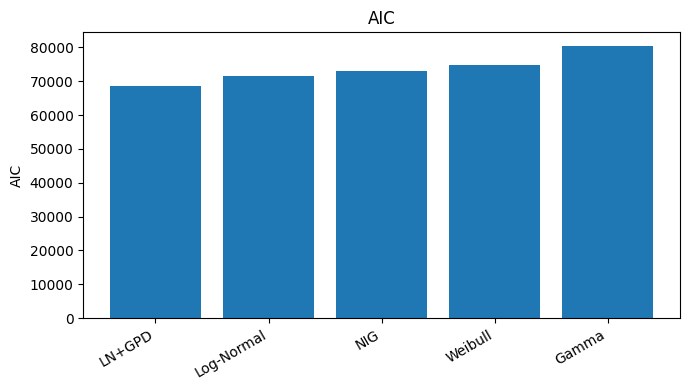

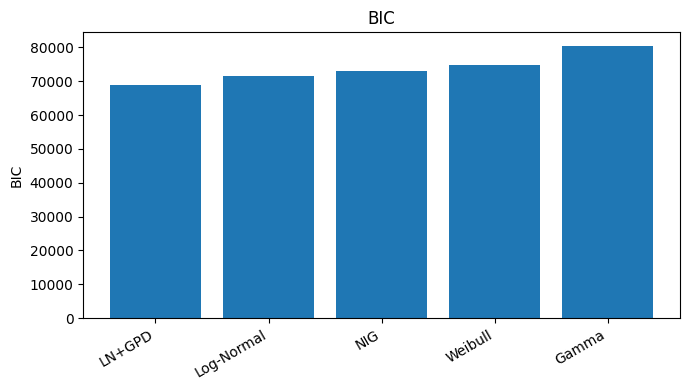

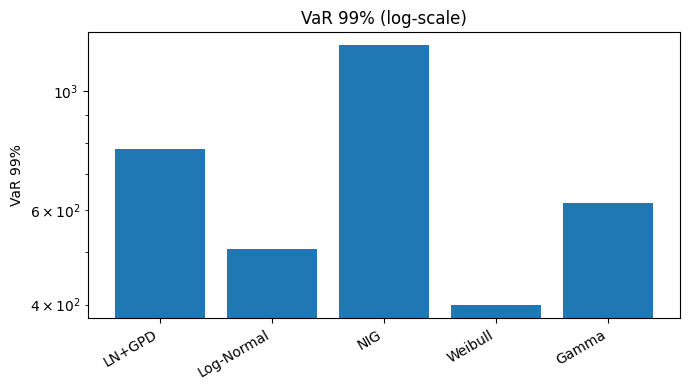

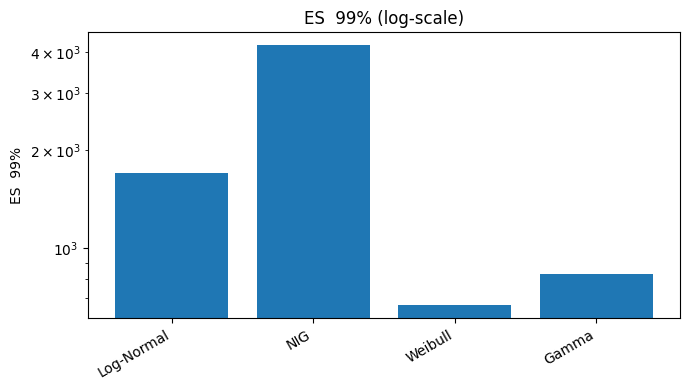

In [103]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()




================ 1. Fitting Single Distributions on Tail Data ================


================ 2. Calculating GPD-Tree Performance on Tail Data ================

GPD-Tree -> Leaves: 6, k: 12, Log-L: -3991.68, AIC: 8007.36, BIC: 8059.06


================ Final Tail Model Comparison (including GPD-Tree) ================

          Distribution  Log-Likelihood       AIC       BIC
GPD-Tree (from LN+GPD)      -3,991.679 8,007.359 8,059.056
            Log-Normal      -4,018.157 8,040.313 8,048.929
                   NIG      -4,019.156 8,046.312 8,063.544
               Weibull      -4,068.420 8,140.840 8,149.456
                 Gamma      -4,114.628 8,233.256 8,241.873


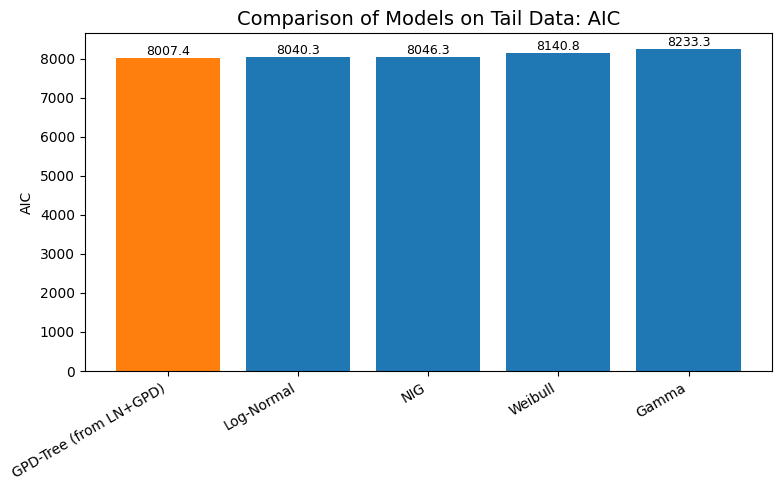

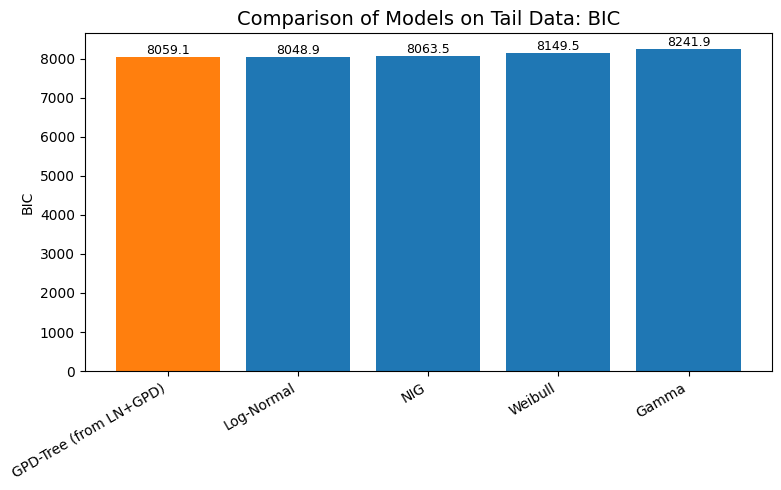

In [104]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
# l1_l2_gpd_patched_new_catprune.py 파일이 같은 디렉토리에 있다고 가정합니다.
import l1_l2_gpd_patched_new_catprune

# =================================================================================
# 0. 필요한 변수들이 이미 생성되어 있다고 가정합니다.
# =================================================================================
# 이 스크립트 실행 전에 다음 변수들이 준비되어 있어야 합니다:
#
# y_tail_excess: 꼬리 데이터의 초과분 (y - u)
# X_tail: 꼬리 데이터의 특성(X) 데이터
# gpd_tail_tree_pruned: 최종적으로 가지치기된 GPD-Tree 객체
# =================================================================================


# =================================================================================
# 1. 평가 및 비교를 위한 헬퍼 함수
# =================================================================================

def fit_single_dist_on_tail(dist, data, name, fix_loc0=True):
    """단일 분포를 꼬리 데이터에 적합하고 AIC/BIC를 계산"""
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data) & (data > 0)]
        if data.size < 10:
            raise ValueError(f"Not enough data points ({data.size})")

        if fix_loc0:
            params = dist.fit(data, floc=0)
            k = len(params) - 1
        else:
            params = dist.fit(data)
            k = len(params)

        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL = float(logpdf.sum())
        n = int(data.size)
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        return {"Distribution": name, "Log-Likelihood": logL, "AIC": aic, "BIC": bic}
    except Exception as e:
        return {"Distribution": name, "Log-Likelihood": f"Fit failed: {e}", "AIC": np.nan, "BIC": np.nan}

# =================================================================================
# 2. 단일 분포들을 꼬리 데이터에 적합
# =================================================================================

# 꼬리 모델링에 적합한 후보 분포들
tail_candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

print("\n================ 1. Fitting Single Distributions on Tail Data ================\n")
single_dist_results = [fit_single_dist_on_tail(dist, y_tail_excess, name, fix_loc0=fix_loc0)
                       for name, (dist, fix_loc0) in tail_candidates.items()]

results_df = pd.DataFrame(single_dist_results)

# =================================================================================
# 3. GPD-Tree 모델의 꼬리 성능 계산 (핵심 부분)
# =================================================================================
print("\n================ 2. Calculating GPD-Tree Performance on Tail Data ================\n")

# 3.1. GPD-Tree의 Log-Likelihood 계산
# get_subtree_nll 함수는 Negative Log-Likelihood (NLL)을 반환합니다.
nll_gpd_tree = l1_l2_gpd_patched_new_catprune.get_subtree_nll(
    gpd_tail_tree_pruned, X_tail, y_tail_excess
)
ll_gpd_tree = -nll_gpd_tree # Log-Likelihood = -NLL

# 3.2. GPD-Tree의 파라미터 수(k) 계산
# 각 리프마다 (sigma, gamma) 2개의 파라미터가 있습니다.
num_leaves_gpd = l1_l2_gpd_patched_new_catprune._num_leaves(gpd_tail_tree_pruned)
k_gpd_tree = 2 * num_leaves_gpd

# 3.3. 꼬리 데이터 샘플 수(n)
n_tail = len(y_tail_excess)

# 3.4. GPD-Tree의 AIC, BIC 계산
aic_gpd_tree = 2 * k_gpd_tree - 2 * ll_gpd_tree
bic_gpd_tree = np.log(n_tail) * k_gpd_tree - 2 * ll_gpd_tree

print(f"GPD-Tree -> Leaves: {num_leaves_gpd}, k: {k_gpd_tree}, Log-L: {ll_gpd_tree:.2f}, AIC: {aic_gpd_tree:.2f}, BIC: {bic_gpd_tree:.2f}")


# =================================================================================
# 4. 최종 비교표 생성 및 출력
# =================================================================================

# GPD-Tree 결과를 DataFrame 행으로 만듭니다.
gpd_tree_row = pd.DataFrame([{
    "Distribution": "GPD-Tree (from LN+GPD)",
    "Log-Likelihood": ll_gpd_tree,
    "AIC": aic_gpd_tree,
    "BIC": bic_gpd_tree,
}])

# 단일 분포 결과와 GPD-Tree 결과를 합치고 AIC 기준으로 정렬합니다.
final_tail_df = (pd.concat([results_df, gpd_tree_row], ignore_index=True)
                 .sort_values("AIC")
                 .reset_index(drop=True))

print("\n\n================ Final Tail Model Comparison (including GPD-Tree) ================\n")
print(final_tail_df.to_string(index=False))


# =================================================================================
# 5. 시각화
# =================================================================================
for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(8, 5))
    plot_df = final_tail_df.dropna(subset=[metric])

    # GPD-Tree를 다른 색으로 강조
    colors = ['C1' if 'GPD-Tree' in x else 'C0' for x in plot_df["Distribution"]]
    bars = plt.bar(plot_df["Distribution"], plot_df[metric], color=colors)

    plt.title(f"Comparison of Models on Tail Data: {metric}", fontsize=14)
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)

    # bar 위에 값 표시
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval, f'{yval:.1f}', va='bottom', ha='center', fontsize=9)

    plt.tight_layout()
    plt.show()

In [44]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Finance.pkl', 'wb') as f:
    pickle.dump(output, f)



#Non EPU

##Comparison

In [46]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {

        'Unemployment Rate_diff': [1],

        'House Price Index_diff': [2],
    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
        'Category_Business Disruption and System Failures',
        'Category_Clients, Products & Business Practices',
        'Category_Damage to Physical Assets',
        'Category_Employment Practices and Workplace Safety',
        'Category_Execution, Delivery & Process Management',
        'Category_External Fraud', 'Category_Internal Fraud',
        'Category_Asset & Wealth Mgmt', 'Category_Asset Servicing & Trust',
        'Category_Banking', 'Category_Brokerage & Advisory',
        'Category_Insurance', 'Category_Investment Banking',
        'Category_Markets & Treasury', 'Category_Others'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)

    if gpd_tail_tree_pruned is not None:
      comparison_results = run_gpd_comparison()



===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=2485.009) N=9931
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=258.332) N=5087
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=61.420) N=4768
      Leaf: N=4160, median=1.25, LN(mu=0.38, sigma=1.61)
      Leaf: N=608, median=0.60, LN(mu=-0.13, sigma=1.64)
    [Category_Asset & Wealth Mgmt ≤ 0.5] (Gain=8.780) N=319
      Leaf: N=296, median=3.92, LN(mu=1.53, sigma=1.51)
      Leaf: N=23, median=10.00, LN(mu=2.11, sigma=1.74)
  [Category_Brokerage & Advisory ≤ 0.5] (Gain=1177.172) N=4844
    [Category_Asset Servicing & Trust ≤ 0.5] (Gain=56.060) N=3917
      Leaf: N=3845, median=6.40, LN(mu=2.08, sigma=2.02)
      Leaf: N=72, median=13.00, LN(mu=2.98, sigma=2.09)
    Leaf: N=927, median=1.45, LN(mu=0.62, sigma=1.93)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=350677.159) N=9931
  [Category_Employment Practices and Workplace Safety ≤ 0.5] (Gain=13947.523) N=5087
    [Category_Asset & Wealth Mgmt ≤ 0.5] (Gain=8890.880) N=4768
      [Category_Investment Banking ≤ 0.5] (Gain=7700.762) N=4671
        Leaf: N=4638, mean=5.41, LN(mu=0.28, sigma=1.60)
        Leaf: N=33, mean=20.74, LN(mu=1.99, sigma=1.88)
      Leaf: N=97, mean=15.19, LN(mu=1.52, sigma=1.97)
    [Category_Banking ≤ 0.5] (Gain=1541.676) N=319
      [Category_Brokerage & Advisory ≤ 0.5] (Gain=519.029) N=198
        Leaf: N=120, mean=15.57, LN(mu=1.84, sigma=1.50)
        Leaf: N=78, mean=12.25, LN(mu=1.55, sigma=1.53)
      Leaf: N=121, mean=9.73, LN(mu=1.32, sigma=1.51)
  [Category_Brokerage & Advisory ≤ 0.5] (Gain=72230.908) N=4844
    [Category_Markets & Treasury ≤ 0.5] (Gain=17748.336) N=3917
      [Category_Insurance ≤ 0.5] (Gain=7881.289) N=3192
        Leaf: N=2073, mean=20.0


===== Pruned GPD CART (Tail, Excesses) =====
[Category_Insurance ≤ 0.5] (PenalizedGain=3.410) N=549
  [Category_Banking ≤ 0.5] (PenalizedGain=1.402) N=482
    [Category_Clients, Products & Business Practices ≤ 0.5] (PenalizedGain=2.199) N=325
      Leaf: N=36, GPD(σ=333.752, γ=0.191), NLL=252.0
      [Category_Asset & Wealth Mgmt ≤ 0.5] (PenalizedGain=1.920) N=289
        Leaf: N=252, GPD(σ=270.426, γ=0.747), NLL=1851.4
        Leaf: N=37, GPD(σ=146.216, γ=1.121), NLL=262.9
    Leaf: N=157, GPD(σ=277.489, γ=0.954), NLL=1190.0
  Leaf: N=67, GPD(σ=168.351, γ=0.665), NLL=455.0

===== Permutation Variable Importance (Tail) =====
[{'name': 'Category_Banking', 'importance': 0.005117000902023067}, {'name': 'Category_Insurance', 'importance': 0.002701129409920967}, {'name': 'Category_Clients, Products & Business Practices', 'importance': 0.002550859636722489}, {'name': 'Category_Asset & Wealth Mgmt', 'importance': 0.000931757212410235}, {'name': 'Unemployment Rate_diff_lag1', 'importance': 0.

In [47]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -4011.28
  단일 GP 로그우도: -4020.22
  LRT statistic = 17.86 (df = 8)
  p‑value = 2.227e-02 -> reject single GP model
  AIC (GP 트리) = 8042.57, AIC (단일 GP) = 8044.43


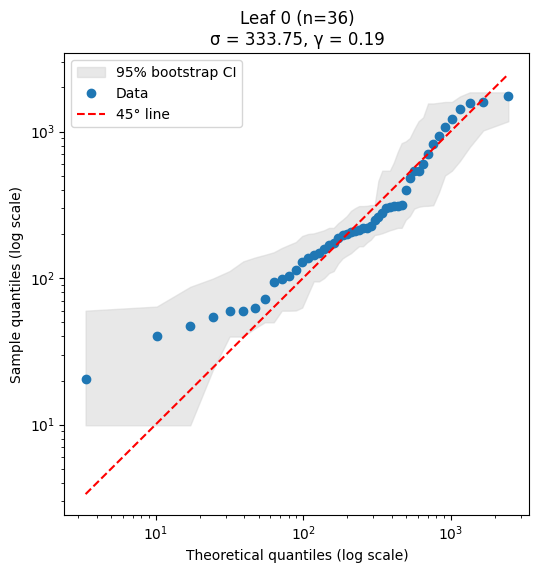

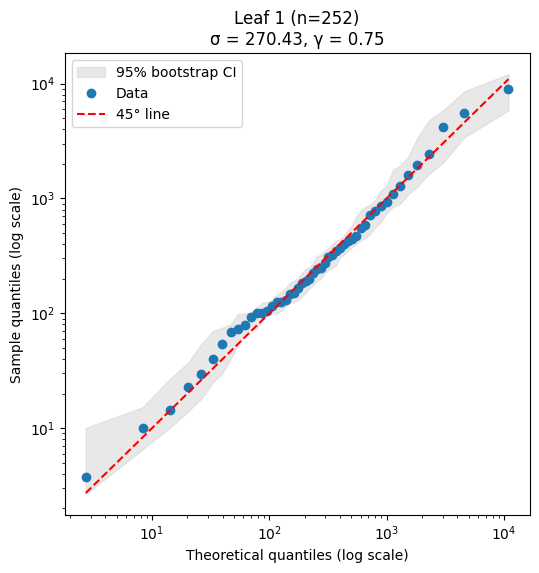

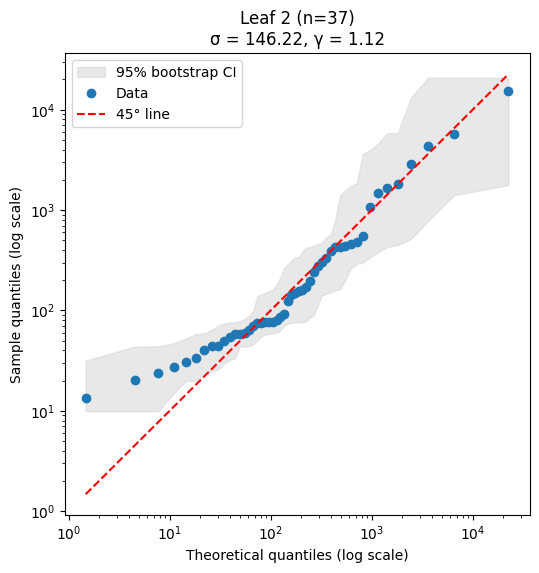

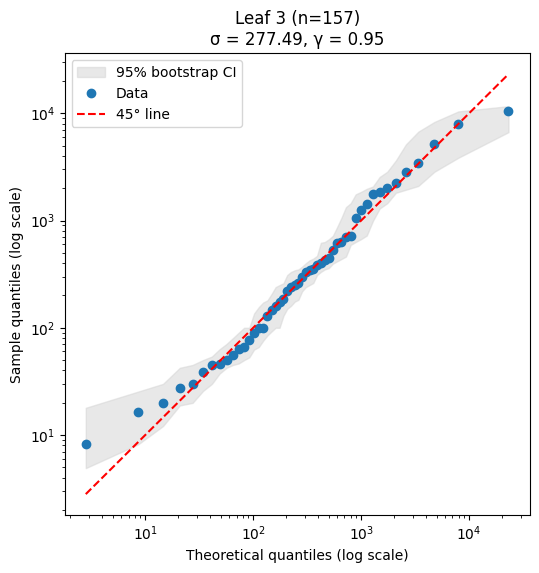

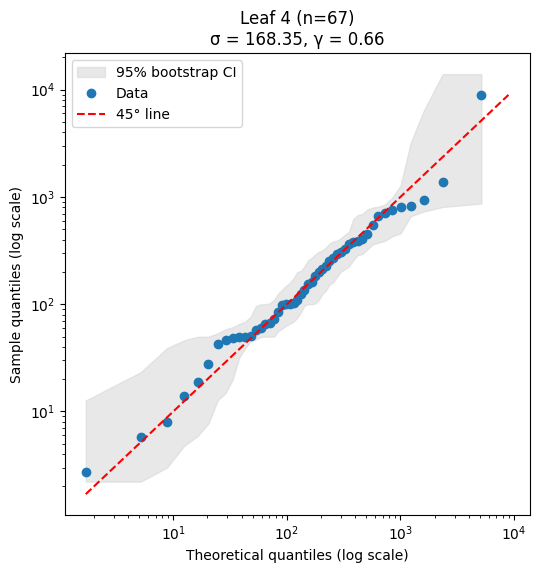

In [48]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [49]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Finance_Non_EPU.pkl', 'wb') as f:
    pickle.dump(output, f)



In [51]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = evaluation.model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = evaluation.model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = evaluation.unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = evaluation.unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = evaluation.unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  = evaluation.unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = evaluation.gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-34464.2, k=20, AIC=68968.5, BIC=69113.6
[LN+GPD]  logL=-34442.5, k=30, AIC=68945.0, BIC=69162.7
99% VaR | LN Only = 748   LN+GPD = 676
99% ES  | LN Only = 3,060   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
136061405956928 157 277.489  0.954    0.059 0.631    0.505 0.205
136061405961280  67 168.351  0.665    0.083 0.708    0.325 0.572
136061405961536  36 333.752  0.191    0.142 0.421    0.598 0.121
136061405962688  37 146.216  1.121    0.108 0.742    0.606 0.116
136061405962816 252 270.426  0.747    0.060 0.318    0.777 0.044


In [52]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%
0   Log-Normal     -35,694.594 71,393.188 71,407.702   508.321 1,702.984
1          NIG     -36,507.317 73,022.634 73,051.662 1,214.637 4,200.303
2      Weibull     -37,359.597 74,723.194 74,737.708   399.059   666.299
3        Gamma     -40,209.881 80,423.762 80,438.276   617.257   829.285



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%  \
0       LN+GPD     -34,442.517 68,945.033 69,162.750   676.259       inf   
1   Log-Normal     -35,694.594 71,393.188 71,407.702   508.321 1,702.984   
2          NIG     -36,507.317 73,022.634 73,051.662 1,214.637 4,200.303   
3      Weibull     -37,359.597 74,723.194 74,737.708   399.059   666.299   
4        Gamma     -40,209.881 80,423.762 80,438.276   617.257   829.285   

       k  
0 30.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


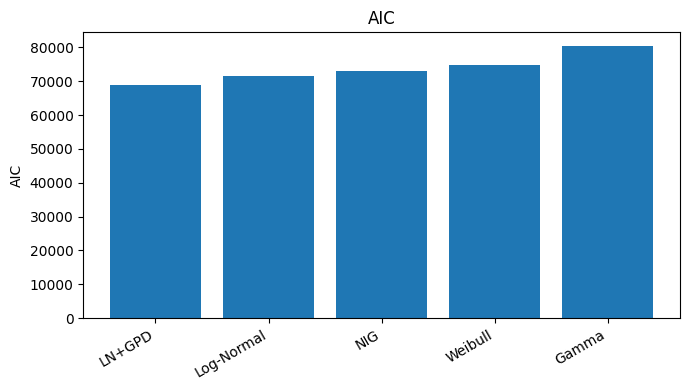

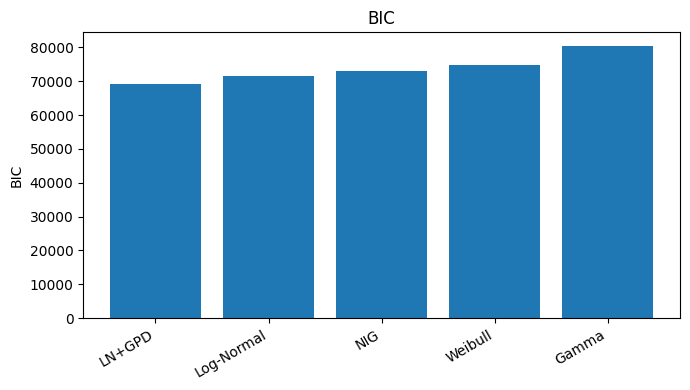

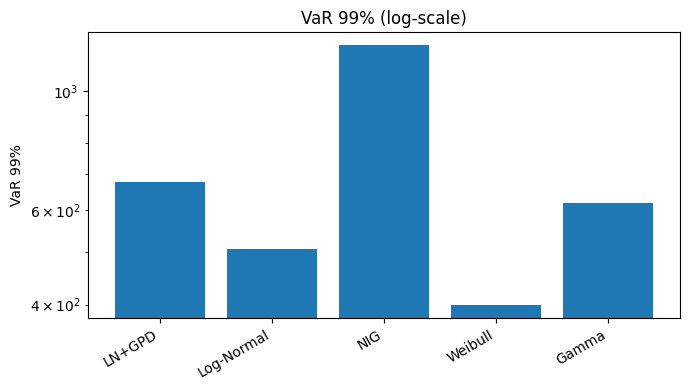

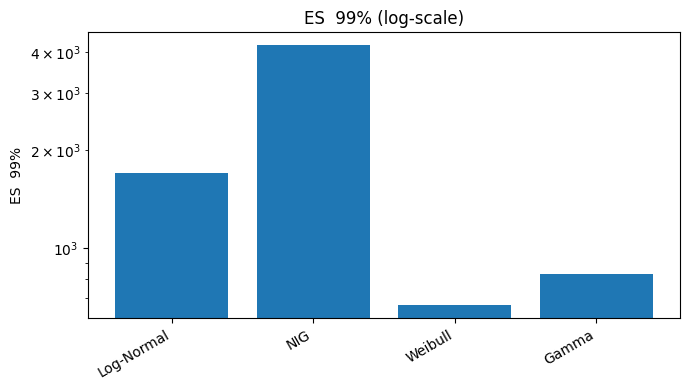

In [53]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()





#Non Finance

In [54]:
df=df1.copy()

In [56]:
us_df = df[df['Country of Incident'] == 'United States']
loss_df = us_df[['First Year of Event','Industry Sector Code','Basel Business Line - Level 2','Event Risk Category','Loss Amount ($M)']].copy()
loss_df.rename(columns={'First Year of Event':'Date', 'Loss Amount ($M)':'Current Value of Loss'}, inplace=True)
loss_df['Date'] = pd.to_datetime(loss_df['Date']).dt.strftime('%Y')
loss_df.sort_values(by='Date', inplace=True)
loss_df = loss_df[loss_df['Date'] >= '1979']


In [57]:
loss_df_finance=loss_df[(loss_df['Industry Sector Code']!=52)]

In [58]:
loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)

/tmp/ipython-input-2474130762.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance.rename(columns={"Basel Business Line - Level 2":"Business"},inplace=True)
/tmp/ipython-input-2474130762.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance.drop(columns=['Industry Sector Code'],inplace=True)


In [59]:
import re
import pandas as pd

# 입력 컬럼
SOURCE_COL = 'Business'

def _norm(x):
    if pd.isna(x):
        return None
    s = str(x).strip().lower()
    # 정규화: & -> and, / -> space, -, , -> space, 괄호 제거, 다중공백 축소
    s = s.replace('&', ' and ')
    s = re.sub(r'[\/,\-]', ' ', s)
    s = re.sub(r'[\(\)\[\]]', ' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    # 특수 케이스 보정
    s = s.replace('foodservices', 'food services')
    s = s.replace('non discretionary', 'non-discretionary')
    return s



# -------------------------------
# 2) 비금융(NAICS류) 상위 그룹 매핑
# -------------------------------
NONFIN_MAP = {
    'manufacturing': 'Manufacturing',
    'construction': 'Construction',
    'utilities': 'Utilities',
    'mining': 'Mining',
    'retail trade': 'Retail Trade',
    'wholesale trade': 'Wholesale Trade',
    'transportation and warehousing': 'Transportation & Warehousing',
    'information': 'Information',
    'educational services': 'Educational Services',
    'health care and social assistance': 'Health Care & Social Assistance',
    'agriculture forestry fishing and hunting': 'Agriculture, Forestry, Fishing & Hunting',
    'real estate rental and leasing': 'Real Estate, Rental & Leasing',
    'accommodation and food services': 'Accommodation & Food Services',
    'arts entertainment and recreation': 'Arts, Entertainment & Recreation',
    'public administration': 'Public Administration',
    'professional scientific and technical services': 'Professional Services',
    'administrative and support waste management and remediation services': 'Admin & Support, Waste Mgmt',
    'management of companies and enterprises': 'Mgmt of Companies & Enterprises',
    'other services except public administration': 'Other Services',
    'non-profit organizations': 'Non-Profit',
}

# -------------------------------
# 3) 키워드 휴리스틱 (미지정 값 보조 분류)
# -------------------------------


def _heuristic_nonfin(key: str):
    # 순서 중요(특정성이 높은 것부터)
    if 'retail trade' in key or (('retail' in key) and ('trade' in key)):
        return 'Retail Trade'
    if 'wholesale' in key:
        return 'Wholesale Trade'
    if 'manufactur' in key:
        return 'Manufacturing'
    if 'construction' in key:
        return 'Construction'
    if 'transportation' in key or 'warehousing' in key:
        return 'Transportation & Warehousing'
    if 'utilities' in key:
        return 'Utilities'
    if any(w in key for w in ['agriculture','forestry','fishing','hunting']):
        return 'Agriculture, Forestry, Fishing & Hunting'
    if 'information' in key:
        return 'Information'
    if 'educational' in key or 'education' in key:
        return 'Educational Services'
    if 'health care' in key or 'social assistance' in key or 'healthcare' in key:
        return 'Health Care & Social Assistance'
    if 'real estate' in key or 'rental' in key or 'leasing' in key:
        return 'Real Estate, Rental & Leasing'
    if 'accommodation' in key or 'food services' in key:
        return 'Accommodation & Food Services'
    if any(w in key for w in ['arts','entertainment','recreation']):
        return 'Arts, Entertainment & Recreation'
    if 'public administration' in key:
        return 'Public Administration'
    if 'professional scientific' in key or 'technical services' in key:
        return 'Professional Services'
    if 'administrative and support' in key or 'waste management' in key or 'remediation' in key:
        return 'Admin & Support, Waste Mgmt'
    if 'management of companies' in key:
        return 'Mgmt of Companies & Enterprises'
    if 'non profit' in key or 'nonprofit' in key:
        return 'Non-Profit'
    if 'other services' in key:
        return 'Other Services'
    return None

# -------------------------------
# 4) 최종 분류 함수
# -------------------------------
def classify_sector_and_line(val):
    key = _norm(val)
    if key is None or key == '':
        return pd.Series(['Unknown', 'Others'])

    # 1) 직접 매핑

    if key in NONFIN_MAP:
        return pd.Series(['Non-Finance', NONFIN_MAP[key]])

    # 2) 휴리스틱(금융 → 비금융 순서)
    nonfin_guess = _heuristic_nonfin(key)
    if nonfin_guess:
        return pd.Series(['Non-Finance', nonfin_guess])

    # 3) 최종 기본값
    return pd.Series(['Unknown', 'Others'])

# 적용: 두 컬럼 생성
loss_df_finance[['SectorType', 'Business_line']] = (
    loss_df_finance[SOURCE_COL].apply(classify_sector_and_line)
)


/tmp/ipython-input-172461346.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance[['SectorType', 'Business_line']] = (
/tmp/ipython-input-172461346.py:118: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loss_df_finance[['SectorType', 'Business_line']] = (


In [60]:
loss_df_finance=loss_df_finance.drop(columns=['Business'])

In [61]:
# Encode 'Event Risk Category'
df_encoded_a = pd.get_dummies(loss_df_finance, columns=['Event Risk Category'], prefix='Category')

# Use the result of the first encoding as input for the second encoding
df_encoded_b = pd.get_dummies(df_encoded_a, columns=['Business_line'], prefix='Category')

# Final encoded DataFrame
loss_df_finance = df_encoded_b.copy()


In [62]:
loss_df_finance.head()

,Date,Current Value of Loss,SectorType,Category_Business Disruption and System Failures,"Category_Clients, Products & Business Practices",Category_Damage to Physical Assets,Category_Employment Practices and Workplace Safety,"Category_Execution, Delivery & Process Management",Category_External Fraud,Category_Internal Fraud,...,Category_Mining,Category_Non-Profit,Category_Other Services,Category_Professional Services,Category_Public Administration,"Category_Real Estate, Rental & Leasing",Category_Retail Trade,Category_Transportation & Warehousing,Category_Utilities,Category_Wholesale Trade
7303,1979,1.200,Non-Finance,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
6211,1979,13.000,Non-Finance,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6133,1979,1.200,Non-Finance,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
6046,1979,80.000,Non-Finance,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4608,1979,13.000,Non-Finance,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [63]:
import re

# ① CSV 읽기
cpu = pd.read_csv('/content/drive/MyDrive/CPU index.csv')[['date', 'cpu_index']]

# ② 전처리 ── 공백 제거
cpu['date'] = cpu['date'].str.strip()

# ③ 'YY-Mon' → 'Mon-YY' 로 재배열
cpu['date'] = cpu['date'].str.replace(
    r'^(\d{2})-([A-Za-z]{3})$',   # 2자리 연도-3자리 월
    r'\2-\1',                     # 월-연도로 바꾸기
    regex=True, flags=re.IGNORECASE
)

# ④ datetime 파싱
cpu['date'] = pd.to_datetime(cpu['date'], format='%b-%y', errors='coerce')

# ⑤ 원하는 포맷(문자열)으로 출력하거나, 월 Period 로도 사용 가능
cpu['date'] = cpu['date'].dt.strftime('%Y-%m')      # 문자열 형태


In [64]:
import pandas as pd
from functools import reduce

file_paths = {
    "us_cpi": "/content/drive/MyDrive/us_cpi.csv",
    "us_unemp": "/content/drive/MyDrive/us_unemp.csv",
    "us_vix": "/content/drive/MyDrive/us_vix.csv",
    "us_m2": "/content/drive/MyDrive/us_m2.csv",
    "us_home_price": "/content/drive/MyDrive/us_home price index.csv",
    "us_T10Y2Y": "/content/drive/MyDrive/us_T10Y2Y.csv",
    "sp500": "/content/drive/MyDrive/sp500_monthly.csv",
}

# Load
us_cpi = pd.read_csv(file_paths["us_cpi"])
us_unemp = pd.read_csv(file_paths["us_unemp"])
#us_vix = pd.read_csv(file_paths["us_vix"])
us_m2 = pd.read_csv(file_paths["us_m2"])
us_home_price = pd.read_csv(file_paths["us_home_price"])
us_T10Y2Y = pd.read_csv(file_paths["us_T10Y2Y"])
sp500 = pd.read_csv(file_paths["sp500"], skiprows=2)

# Rename columns for consistency
us_T10Y2Y.rename(columns={'T10Y2Y': '10_2'}, inplace=True)
us_home_price.rename(columns={'USSTHPI': 'House Price Index'}, inplace=True)
us_m2.rename(columns={'WM2NS': 'M2'}, inplace=True)
#us_vix.rename(columns={'VIXCLS': 'VIX'}, inplace=True)
us_cpi.rename(columns={'CPIAUCSL': 'CPI'}, inplace=True)
us_unemp.rename(columns={'UNRATE': 'Unemployment Rate'}, inplace=True)
sp500.rename(columns={'Unnamed: 1': 'Close'}, inplace=True)
sp500=sp500.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4", "Unnamed: 5"])
sp500.rename(columns={'date': 'Date'}, inplace=True)
cpu.rename(columns={'date': 'Date'}, inplace=True)

# 1) Date 컬럼을 년(YYYY)으로만 변환
for df in [us_cpi, us_unemp, us_m2, us_home_price, us_T10Y2Y, sp500,cpu]:
    # 바깥에서 "Date" 컬럼 명으로 통일
    df.rename(columns={df.columns[0]: "Date"}, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"]).dt.year  # 년도로만 추출

# 2) 연 단위 집계: "마지막 값" or "평균" 등 선택
#   여기서는 예시로 평균값 사용
us_T10Y2Y = us_T10Y2Y.groupby("Date").mean().reset_index()
us_home_price = us_home_price.groupby("Date").mean().reset_index()
us_m2 = us_m2.groupby("Date").mean().reset_index()
us_cpi = us_cpi.groupby("Date").mean().reset_index()
us_unemp = us_unemp.groupby("Date").mean().reset_index()
sp500 = sp500.groupby("Date").mean().reset_index()
cpu = cpu.groupby("Date").mean().reset_index()

# us_cpi['CPI_diff']=np.log(us_cpi['CPI']).diff()
# us_home_price['House Price Index_diff']=np.log(us_home_price['House Price Index']).diff()
# us_unemp['Unemployment Rate_diff']=np.log(us_unemp['Unemployment Rate']).diff()
# us_m2['M1_diff']=np.log(us_m2['M1']).diff()

sp500['Close_diff']=np.log(sp500['Close']).diff()
sp500.fillna(0.1635259493925565,inplace=True)

# 3) 머지
dfs = [us_T10Y2Y, us_home_price, us_m2,  us_cpi, us_unemp,sp500,cpu]
df_merged_macro = reduce(lambda left, right: pd.merge(left, right, on="Date", how="inner"), dfs)


df_merged_macro_lag=df_merged_macro.copy()
df_merged_macro_lag = df_merged_macro_lag[df_merged_macro_lag["Date"] >= 1980]
df_merged_macro_lag['Date']=df_merged_macro_lag['Date'].astype(str)

In [65]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.preprocessing import MinMaxScaler
from scipy.optimize import minimize
from scipy.stats import genpareto
import copy
#1986부터 사용
#############################################
# 1. 데이터 전처리 (연 단위)
#############################################
# (1) 엑셀 파일 읽기 및 날짜 정리
# 실제 파일 경로로 수정하세요.

epu_kr_path = '/content/drive/MyDrive/Korea_Overall_EPU.xlsx'
epu_kr_cat_path = '/content/drive/MyDrive/Korea_Categorical_PU_Indices.xlsx'
epu_usa_path = '/content/drive/MyDrive/US_Policy_Uncertainty_Data.xlsx'
epu_usa_cat_path = '/content/drive/MyDrive/Categorical_EPU_Data.xlsx'


# 미국 EPU 데이터
epu_usa = pd.read_excel(epu_usa_path)
epu_usa_cat = pd.read_excel(epu_usa_cat_path)
# 연도만 추출 (datetime 변환 후 정수형으로)
epu_usa['Year'] = pd.to_datetime(epu_usa['Year'], format='%Y').dt.year.astype(int)
epu_usa_cat['Year'] = pd.to_datetime(epu_usa_cat['Year'], format='%Y').dt.year.astype(int)
# 연도 필터링 (1985~2022)
epu_usa_cl = epu_usa[(epu_usa['Year'] < 2023)].copy()
epu_usa_cat_cl = epu_usa_cat[ (epu_usa_cat['Year'] < 2023)].copy()
# 최종적으로 'Date' 컬럼에 연도만(문자형) 저장
epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)
epu_usa_cl_lag = epu_usa_cl.copy()
epu_usa_cat_cl_lag = epu_usa_cat_cl.copy()


epu_usa_cl['Date'] = epu_usa_cl['Year'].astype(str)

epu_overall = (
    epu_usa_cl
    .groupby('Date')[['Three_Component_Index','News_Based_Policy_Uncert_Index']]
    .mean()
    .reset_index()
)

# 2) 범주형 EPU 연평균 집계
# ————————
cat_cols = [
    '1. Economic Policy Uncertainty','2. Monetary policy',
    'Fiscal Policy (Taxes OR Spending)','3. Taxes',
    '4. Government spending','5. Health care',
    '6. National security','7. Entitlement programs',
    '8. Regulation','Financial Regulation',
    '9. Trade policy','10. Sovereign debt, currency crises'
]
epu_usa_cat_cl['Date'] = epu_usa_cat_cl['Year'].astype(str)

epu_cats = (
    epu_usa_cat_cl
    .groupby('Date')[cat_cols]
    .mean()
    .reset_index()
)

# 3) 매크로 + EPU(전체+범주) 병합
# ———————————————
df_macro_epu = (
    df_merged_macro_lag
    .merge(epu_overall, on='Date', how='inner')
    .merge(epu_cats,    on='Date', how='inner')
)

# 4) 최종: 이벤트 손실(≈433행)과 1:1 병합
# ——————————————————————
final_df = df_macro_epu.merge(loss_df_finance, on='Date', how='inner')

print(final_df.shape)  # → (≈433, 원하는 컬럼만)


(11024, 52)


In [66]:
df_merged=final_df.copy()
df_merged['Exceedance']=df_merged['Current Value of Loss']

In [67]:
df_merged.to_csv('/content/drive/MyDrive/df_EPU_Non_Finance.csv',index=False)

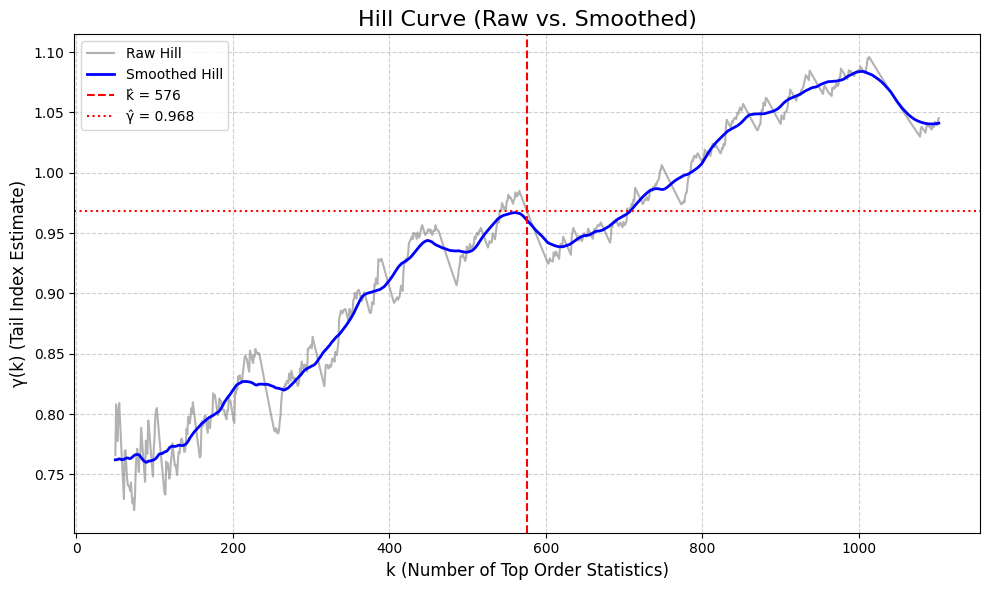

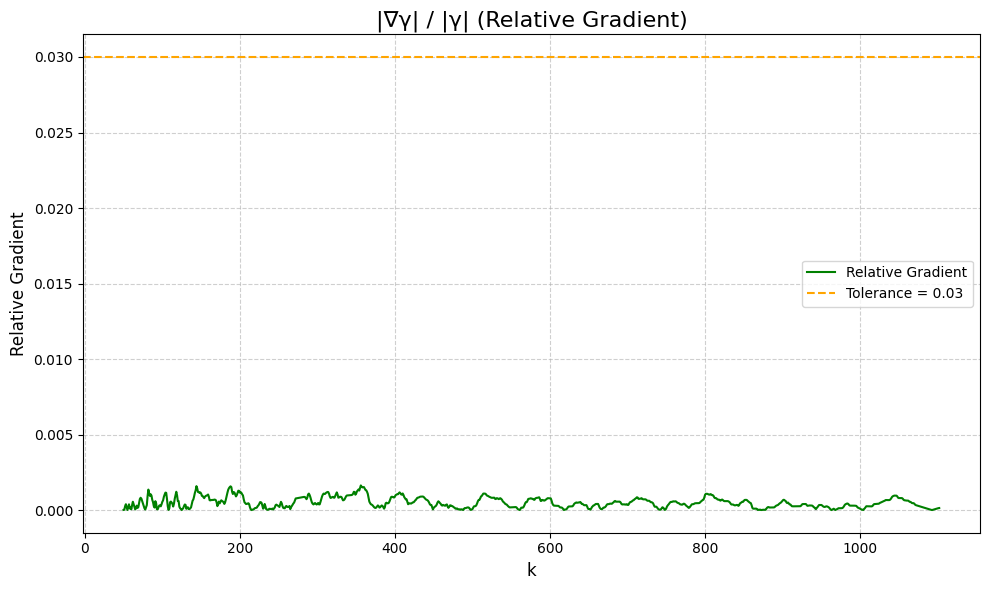

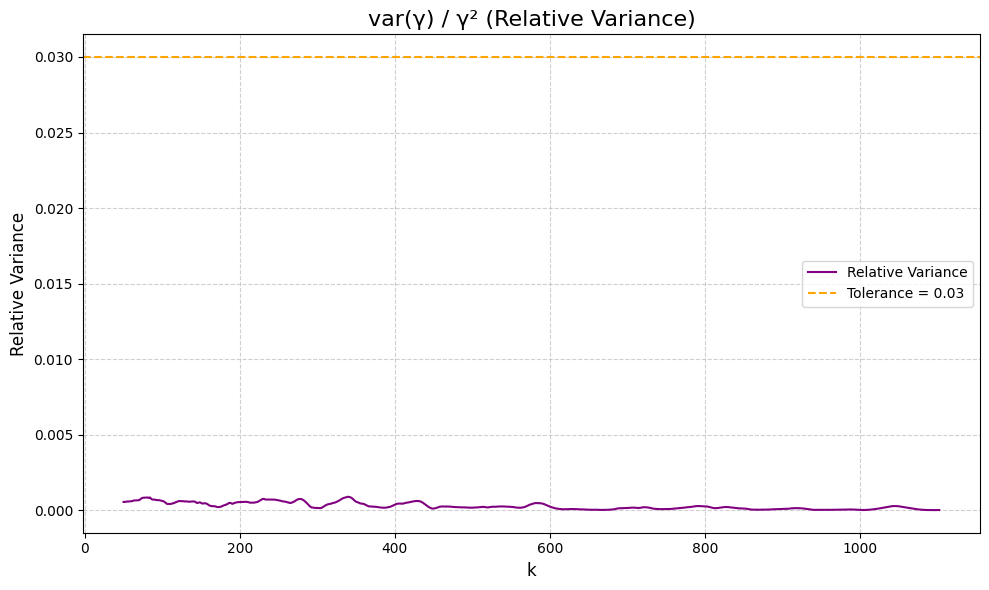

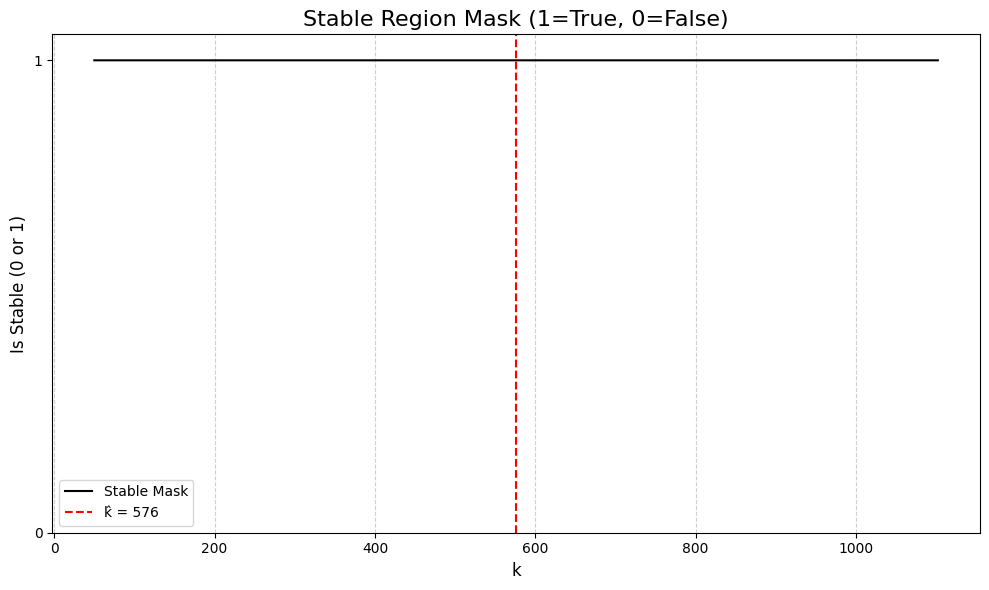


--- Results ---
Estimated Threshold (u_hat): 200.0000
Number of Exceedances (k_hat): 576
Estimated Tail Index (gamma_hat): 0.9679
----------------


In [68]:
# hill_plots.py ─────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from typing import Optional, Tuple, Dict, Any

# It's assumed that the 'thresholding' module you created is in the same folder.
from hill_plot_new_patched import select_threshold, HillDiag

def _compute_hill_raw_curve(y: np.ndarray, ks: np.ndarray) -> np.ndarray:
    """
    Computes the raw (unsmoothed) Hill curve.
    γ_k = mean( log Y_(1..k) - log Y_(k+1) ), where Y are sorted positive values.
    """
    y = np.asarray(y, dtype=float)
    y = y[np.isfinite(y)]
    y_desc = np.sort(y)[::-1]
    y_pos = y_desc[y_desc > 0]
    if y_pos.size < 2 or ks.size == 0: # Need at least 2 points to compute log-differences
        return np.array([])

    # Ensure k does not exceed valid index
    max_k = y_pos.size - 1
    valid_ks = ks[ks < max_k]
    if valid_ks.size == 0:
        return np.array([])

    return np.array([np.mean(np.log(y_pos[:k]) - np.log(y_pos[k])) for k in valid_ks], dtype=float)

def plot_hill_curve(
    y: np.ndarray,
    diag: HillDiag,
    k_hat: int,
    gamma_hat: float,
    *,
    title: str = "Hill Curve (Raw vs. Smoothed)",
) -> None:
    """
    Plots the Hill curve (raw vs. smoothed) and the estimated point (k_hat, gamma_hat).
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot Hill curve.")
        return

    gamma_raw = _compute_hill_raw_curve(y, diag.k_grid)

    plt.figure(figsize=(10, 6))
    if gamma_raw.size:
        # Match raw curve to its valid k-grid
        max_k_raw = y.size - 1
        valid_ks_raw = diag.k_grid[diag.k_grid < max_k_raw]
        plt.plot(valid_ks_raw, gamma_raw, label="Raw Hill", alpha=0.6, color='gray')

    plt.plot(diag.k_grid, diag.gamma_hat, label="Smoothed Hill", color='blue', linewidth=2)
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.axhline(gamma_hat, linestyle=":", color='red', label=f"γ̂ = {gamma_hat:.3f}")

    plt.title(title, fontsize=16)
    # CHANGED: Korean -> English
    plt.xlabel("k (Number of Top Order Statistics)", fontsize=12)
    plt.ylabel("γ(k) (Tail Index Estimate)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_grad_norm(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    title: str = "|∇γ| / |γ| (Relative Gradient)"
) -> None:
    """Plots the relative gradient and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot grad_norm.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.grad_norm, label="Relative Gradient", color='green')
    plt.axhline(rel_grad_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_grad_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Gradient", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_var_rel(
    diag: HillDiag,
    *,
    rel_var_tol: float,
    title: str = "var(γ) / γ² (Relative Variance)"
) -> None:
    """Plots the relative variance and the tolerance line."""
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot var_rel.")
        return

    plt.figure(figsize=(10, 6))
    plt.plot(diag.k_grid, diag.var_rel, label="Relative Variance", color='purple')
    plt.axhline(rel_var_tol, linestyle="--", color='orange', label=f"Tolerance = {rel_var_tol}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Relative Variance", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_stable_mask(
    diag: HillDiag,
    *,
    rel_grad_tol: float,
    rel_var_tol: float,
    gamma_min: float,
    k_hat: int,
    title: str = "Stable Region Mask (1=True, 0=False)"
) -> None:
    """
    Visualizes the stable region mask:
    stable = (grad_norm < rel_grad_tol) & (var_rel < rel_var_tol) & (gamma_hat > gamma_min)
    """
    if diag.k_grid.size == 0:
        # CHANGED: Korean -> English
        print("diag.k_grid is empty: Cannot plot stable mask.")
        return

    stable = (diag.grad_norm < rel_grad_tol) & (diag.var_rel < rel_var_tol) & (diag.gamma_hat > gamma_min)

    plt.figure(figsize=(10, 6))
    plt.step(diag.k_grid, stable.astype(int), where="mid", label="Stable Mask", color='black')
    plt.axvline(k_hat, linestyle="--", color='red', label=f"k̂ = {k_hat}")
    plt.title(title, fontsize=16)
    plt.xlabel("k", fontsize=12)
    plt.ylabel("Is Stable (0 or 1)", fontsize=12)
    plt.yticks([0, 1])
    plt.legend()
    plt.grid(True, axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_hill_diagnostics(
    y: np.ndarray,
    *,
    # Parameters for thresholding._auto_hill
    k_min: int = 50,
    k_max_prop: float = 0.1,
    window: int = 61,
    rel_grad_tol: float = 0.04,
    rel_var_tol: float = 0.03,
    gamma_min: float = 0.02,
    min_plateau_len: int = 10,
    plateau_strategy: str = "longest",
    min_excess: Optional[int] = None,
    max_excess: Optional[int] = None,
    # Optional titles for individual plots
    titles: Optional[Dict[str, str]] = None,
    # For passing extra args to select_threshold
    extra_hill_kwargs: Optional[Dict[str, Any]] = None,
) -> Tuple[float, int, float, HillDiag]:
    """
    In a single call, this function:
      1) Runs select_threshold to get (u_hat, k_hat, gamma_hat, diag).
      2) Generates separate plots for Hill curve, grad_norm, var_rel, and stable mask.

    Returns: (u_hat, k_hat, gamma_hat, diag)
    """
    if titles is None:
        titles = {}
    if extra_hill_kwargs is None:
        extra_hill_kwargs = {}

    # Call select_threshold requesting the diagnostic data
    u_hat, k_hat, gamma_hat, diag = select_threshold(
        y,
        return_diag=True,
        k_min=k_min,
        k_max_prop=k_max_prop,
        window=window,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        min_plateau_len=min_plateau_len,
        plateau_strategy=plateau_strategy,
        min_excess=min_excess,
        max_excess=max_excess,
        **extra_hill_kwargs,
    )

    # 1) Hill Curve
    plot_hill_curve(
        y, diag, k_hat, gamma_hat,
        title=titles.get("hill", "Hill Curve (Raw vs. Smoothed)")
    )

    # 2) grad_norm
    plot_grad_norm(
        diag,
        rel_grad_tol=rel_grad_tol,
        title=titles.get("grad", "|∇γ| / |γ| (Relative Gradient)")
    )

    # 3) var_rel
    plot_var_rel(
        diag,
        rel_var_tol=rel_var_tol,
        title=titles.get("var", "var(γ) / γ² (Relative Variance)")
    )

    # 4) stable mask
    plot_stable_mask(
        diag,
        rel_grad_tol=rel_grad_tol,
        rel_var_tol=rel_var_tol,
        gamma_min=gamma_min,
        k_hat=k_hat,
        title=titles.get("stable", "Stable Region Mask (1=True, 0=False)")
    )

    return u_hat, k_hat, gamma_hat, diag


if __name__ == "__main__":

    # Run the diagnostic plotting function
    u_hat, k_hat, gamma_hat, diag = plot_hill_diagnostics(
        df_merged['Exceedance'],
        k_min=50,
        k_max_prop=0.1, # Use a larger proportion for better visualization
        window=61,
        rel_grad_tol=0.03,
        rel_var_tol=0.03, # Loosen var tolerance slightly for demo
        gamma_min=0.02,
        min_plateau_len=20,
        plateau_strategy="longest",
    )

    print("\n--- Results ---")
    print(f"Estimated Threshold (u_hat): {u_hat:.4f}")
    print(f"Number of Exceedances (k_hat): {k_hat}")
    print(f"Estimated Tail Index (gamma_hat): {gamma_hat:.4f}")
    print("----------------")

In [69]:
n = len(df_merged['Exceedance'])
top_percent = (k_hat / n) * 100
print(f"Top {top_percent:.2f}% of data exceed threshold {u_hat:.2f}")


Top 5.22% of data exceed threshold 200.00


#ADF

In [70]:

df = df_merged.copy()

# 1) 연도 만들기
if not pd.api.types.is_integer_dtype(df['Date']):
    df['Year'] = pd.to_datetime(df['Date']).dt.year
else:
    df['Year'] = df['Date']

# 2) 대상/피처/카테고리 정의
target_col = 'Exceedance'  # 타깃은 연도 총합으로 집계
base_vars = ['10_2','House Price Index','M1','CPI','Unemployment Rate',
             'Close','Close_diff','Three_Component_Index',
             'News_Based_Policy_Uncert_Index','1. Economic Policy Uncertainty',
             '2. Monetary policy','Fiscal Policy (Taxes OR Spending)','3. Taxes',
             '4. Government spending','5. Health care','6. National security',
             '7. Entitlement programs','8. Regulation','Financial Regulation',
             '9. Trade policy','10. Sovereign debt, currency crises','cpu_index']

# 이미 차분된 컬럼(예: Close_diff)은 이중 차분 방지를 위해 제외 권장
base_vars_clean = [c for c in base_vars if c in df.columns and not c.endswith('_diff') and c != target_col]
cat_cols = [c for c in df.columns if c.startswith('Category_')]

# 3) 집계 규칙: 타깃=sum, 매크로(이미 연평균된 값)=first, 카테고리 더미=max
agg_dict = {
    target_col: 'sum',
    **{c: 'first' for c in base_vars_clean},
    **{c: 'max' for c in cat_cols}
}

# 4) 연도 단위로 집계 -> 정렬 -> 인덱스 리셋
df_year = (df.groupby('Year', as_index=False)
             .agg(agg_dict)
             .sort_values('Year')
             .reset_index(drop=True))

# 4-1) 연도별 사건 수(N_t) 계산 후 병합 (원하면 나중에 그랜저에 포함해서 테스트 가능)
cnt = df.groupby('Year').size().rename('N_t').reset_index()
df_year = df_year.merge(cnt, on='Year', how='left')

# 5) 타깃 안정화 (합은 스케일이 커서 log1p 권장; 음수 없을 때만)
if (df_year[target_col] >= 0).all():
    df_year[target_col] = np.log1p(df_year[target_col])

# 6) 숫자형 보정 및 결측 제거(Granger는 NaN 불가)
cols_to_numeric = [target_col] + base_vars_clean + cat_cols + ['N_t']
for col in cols_to_numeric:
    if col in df_year.columns:
        df_year[col] = pd.to_numeric(df_year[col], errors='coerce')

# 그랜저에 쓸 핵심 컬럼만 NaN 제거
df_granger = df_year.dropna(subset=[target_col] + base_vars_clean)

# 7) 그랜저 파이프라인 실행 (연 단위이므로 max_lag를 3으로 낮춤 권장)
res = granger_analysis.run_granger_analysis_pipeline(
    df_granger,
    base_vars=base_vars_clean,      # N_t도 원하면 base_vars에 추가해서 N_t→타깃 테스트 가능
    target_col=target_col,
    transform='auto',
    max_lag=3
)

summary_df = recent_lag.get_most_recent_granger_lags(
    granger_df=res,
    target_variable=target_col
)

print("--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---")
print(summary_df)


--- 1. Starting Analysis Pipeline ---

--- 2. Checking variable stationarity (ADF Test) ---
Stationary variables: ['Unemployment Rate', '2. Monetary policy', '4. Government spending', '6. National security', '9. Trade policy', '10. Sovereign debt, currency crises']
Non-stationary variables to be differenced: ['10_2', 'House Price Index', 'CPI', 'Close', 'Three_Component_Index', 'News_Based_Policy_Uncert_Index', '1. Economic Policy Uncertainty', 'Fiscal Policy (Taxes OR Spending)', '3. Taxes', '5. Health care', '7. Entitlement programs', '8. Regulation', 'Financial Regulation', 'cpu_index', 'Exceedance']

--- 3. Applying 'auto' differencing ---

--- 4. Running Granger Causality Test on processed data ---
Base variables: ['10_2_diff', 'House Price Index_diff', 'CPI_diff', 'Unemployment Rate', 'Close_diff', 'Three_Component_Index_diff', 'News_Based_Policy_Uncert_Index_diff', '1. Economic Policy Uncertainty_diff', '2. Monetary policy', 'Fiscal Policy (Taxes OR Spending)_diff', '3. Taxes_di

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print resul


--- 5. Analysis Complete ---
'Exceedance'에 영향을 미치는 유의미한 변수를 찾지 못했습니다.
--- 변수별 가장 빠른 유의미한 시차 (Lag) 요약 ---
Empty DataFrame
Columns: [Causal_Var, Most_Recent_Lag]
Index: []


##Comparison

In [72]:
M = l1_l2_gpd_patched_new_catprune

# ---------- Main ----------
if __name__ == "__main__":

    # --- Configuration ---
    TARGET_VARIABLE = "Exceedance"
    DATE_COLUMN = "Date"
    START_YEAR = 1985

    # Selected lags
    selected_lags_dict = {

    }

    # Categorical features (assumed to be 0/1)
    categorical_cols_list = [
'Category_Business Disruption and System Failures',
       'Category_Clients, Products & Business Practices',
       'Category_Damage to Physical Assets',
       'Category_Employment Practices and Workplace Safety',
       'Category_Execution, Delivery & Process Management',
       'Category_External Fraud', 'Category_Internal Fraud',
       'Category_Accommodation & Food Services',
       'Category_Admin & Support, Waste Mgmt',
       'Category_Agriculture, Forestry, Fishing & Hunting',
       'Category_Arts, Entertainment & Recreation', 'Category_Construction',
       'Category_Educational Services',
       'Category_Health Care & Social Assistance', 'Category_Information',
       'Category_Manufacturing', 'Category_Mgmt of Companies & Enterprises',
       'Category_Mining', 'Category_Non-Profit', 'Category_Other Services',
       'Category_Professional Services', 'Category_Public Administration',
       'Category_Real Estate, Rental & Leasing', 'Category_Retail Trade',
       'Category_Transportation & Warehousing', 'Category_Utilities',
       'Category_Wholesale Trade'
    ]

    # --- Data Loading and Preparation ---
    # If df_merged is not defined, make a synthetic demo
    if 'df_merged' not in locals() or not isinstance(df_merged, pd.DataFrame):
        l1_l2_gpd_patched_new_catprune.logging.warning("'df_merged' DataFrame not found. Generating synthetic data.")
        n_years = 40
        dates = pd.date_range(start='1980-01-01', periods=n_years, freq='YS')
        data = {'Date': dates}
        all_needed_cols = list(selected_lags_dict.keys()) + categorical_cols_list + [TARGET_VARIABLE]
        rng = np.random.default_rng(42)
        for col in all_needed_cols:
            if col == TARGET_VARIABLE:  # positive, heavy-tailed-ish
                data[col] = rng.pareto(a=1.5, size=n_years) * 1000 + 1.0
            elif col.startswith("Category_"):
                data[col] = rng.integers(0, 2, size=n_years)
            else:
                data[col] = rng.standard_normal(n_years).cumsum() + 100.0
        df_merged = pd.DataFrame(data)

    # Create the dataset with lagged features
    try:
        df_model_ready, feature_names_list = l1_l2_gpd_patched_new_catprune.create_lagged_features(
            df=df_merged,
            target_col=TARGET_VARIABLE,
            lag_config=selected_lags_dict,
            date_col=DATE_COLUMN,
            start_year=START_YEAR,
            additional_features=categorical_cols_list
        )
    except Exception as e:
        l1_l2_gpd_patched_new_catprune.logging.error(f"Error creating lagged features: {e}")
        raise

    if df_model_ready.empty:
        l1_l2_gpd_patched_new_catprune.logging.error(
            "Resulting DataFrame is empty after processing. Check input data and parameters."
        )
        raise SystemExit(1)

        # ---------- Matrix build ----------
    features_df = (
        df_model_ready[feature_names_list]
          .apply(pd.to_numeric, errors='coerce')           # "0"/"1" → 0/1, non-numeric → NaN
          .replace([np.inf, -np.inf], np.nan)
    )

    # 간단한 결측 처리(중앙값 대체). 필요 시 본인 로직으로 교체 가능
    if features_df.isna().any().any():
        features_df = features_df.fillna(features_df.median(numeric_only=True))

    # 최종 설계: float 행렬로 강제
    X_all_data = features_df.to_numpy(dtype=float)

    # 타깃도 안전 변환
    y_all_data = (
        pd.to_numeric(df_model_ready[TARGET_VARIABLE], errors='coerce')
          .replace([np.inf, -np.inf], np.nan)
          .fillna(df_model_ready[TARGET_VARIABLE].median())
          .to_numpy(dtype=float)
    )

    # (선택) 디버그: 여전히 object가 섞였는지 체크
    if X_all_data.dtype != float:
        raise TypeError(f"Design matrix dtype must be float, got {X_all_data.dtype}")

    # ---------- Threshold (AS-IS from user) ----------
    # Do NOT touch user's threshold estimator; we expect u_hat to be defined by user.
    u_threshold = u_hat  # <-- as requested: use user-supplied threshold

    # ---------- Bulk / Tail split ----------
    mask_bulk = y_all_data <= u_threshold
    mask_tail = ~mask_bulk

    X_bulk, y_bulk = X_all_data[mask_bulk], y_all_data[mask_bulk]
    X_tail = X_all_data[mask_tail]
    y_tail = y_all_data[mask_tail] - u_threshold  # excesses for GPD

    l1_l2_gpd_patched_new_catprune.logging.info(
        f"Data split: Bulk = {len(y_bulk)} samples, Tail (Excesses) = {len(y_tail)} samples."
    )

    # Check tail size
    MIN_TAIL_SAMPLES = 50
    if len(y_tail) < MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            f"Tail dataset size ({len(y_tail)}) is small. GPD results may be unreliable."
        )

    # ---------- Model Fitting ----------

    # 1) L1 CART (Median) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L1 CART (Median) for Bulk Data...")
    l1_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
        X_bulk, y_bulk, feature_names_list, min_leaf=20, max_depth=3
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l1_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L1 CART (Bulk, Median-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l1_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l1_bulk_tree)

    # 2) L2 CART (Mean) + LogNormal for Bulk
    l1_l2_gpd_patched_new_catprune.logging.info("Fitting L2 CART (Mean) for Bulk Data...")
    l2_bulk_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l2(
        X_bulk, y_bulk, feature_names_list, min_leaf=30, max_depth=4
    )
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(l2_bulk_tree, X_bulk, y_bulk, trunc_right=u_threshold)

    print("\n===== L2 CART (Bulk, Mean-based) =====")
    l1_l2_gpd_patched_new_catprune.print_tree_structure(l2_bulk_tree, feature_names_list)
    l1_l2_gpd_patched_new_catprune.validate_tree_structure(l2_bulk_tree)

    # 3) GPD CART for Tail (Excesses)
    gpd_tail_tree_pruned = None
    if len(y_tail) >= MIN_TAIL_SAMPLES:
        l1_l2_gpd_patched_new_catprune.logging.info("Fitting GPD CART for Tail Data (Excesses)...")

        # Grow initial large tree
        gpd_tail_tree_raw = l1_l2_gpd_patched_new_catprune.grow_tree_gpd(
            X_tail, y_tail, feature_names_list, min_leaf=max(30, int(0.05 * len(y_tail))), max_depth=4
        )

        # Repair, print, validate
        if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
            l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_raw)

        print("\n===== Raw GPD CART (Tail, Excesses) =====")
        l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_raw, feature_names_list)
        l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_raw, min_samples_leaf=10)

        # CV pruning
        l1_l2_gpd_patched_new_catprune.logging.info("Pruning GPD CART using Cross-Validation...")
        try:
            cv_folds = min(5, max(2, len(y_tail) // 10))
            gpd_tail_tree_pruned, best_alpha_gpd = l1_l2_gpd_patched_new_catprune.prune_gpd_with_cv(
                gpd_tail_tree_raw, X_tail, y_tail,
                n_folds=cv_folds,
                cv_min_leaf_ratio=0.02,
                cv_min_leaf_floor=max(20, int(0.05 * len(y_tail))),  # robust floor
                use_one_se=True,
                use_mean_nll=True,
                guard_root=True
            )
            l1_l2_gpd_patched_new_catprune.logging.info(
                f"GPD CART Pruning complete. Best alpha = {best_alpha_gpd:.4g}"
            )

            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)

            print("\n===== Pruned GPD CART (Tail, Excesses) =====")
            l1_l2_gpd_patched_new_catprune.print_tree_structure(gpd_tail_tree_pruned, feature_names_list)
            l1_l2_gpd_patched_new_catprune.validate_tree_structure(gpd_tail_tree_pruned, min_samples_leaf=10)

        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.error(
                f"GPD Tree Pruning failed: {e}. Using raw tree."
            )
            gpd_tail_tree_pruned = gpd_tail_tree_raw
            if hasattr(l1_l2_gpd_patched_new_catprune, "_repair_tree_inplace"):
                l1_l2_gpd_patched_new_catprune._repair_tree_inplace(gpd_tail_tree_pruned)
    else:
        l1_l2_gpd_patched_new_catprune.logging.warning(
            "Skipping GPD CART fitting due to insufficient tail data."
        )

    # ---------- Diagnostics: Moments, CI, Importance ----------
    if gpd_tail_tree_pruned is not None:
        # Warn if some leaves imply infinite mean (gamma >= 1)
        if hasattr(l1_l2_gpd_patched_new_catprune, "warn_leaf_moments"):
            l1_l2_gpd_patched_new_catprune.warn_leaf_moments(gpd_tail_tree_pruned, mean_guard=1.0, near_tol=0.95)

        # Leaf-wise CI for gamma
        try:
            # Many implementations use callbacks; we pass module's helpers if present
            ci_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                ci_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            if hasattr(l1_l2_gpd_patched_new_catprune, "_get_all_leaves"):
                ci_kwargs["get_leaves"] = l1_l2_gpd_patched_new_catprune._get_all_leaves
            # Fallback getter for leaf params
            def _get_leaf_params(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    return (np.nan, np.nan)
                return (float(gp[0]), float(gp[1]))
            ci_kwargs.setdefault("get_leaf_params", _get_leaf_params)

            cis = l1_l2_gpd_patched_new_catprune.leaf_confidence_intervals(
                gpd_tail_tree_pruned, X_tail, y_tail, **ci_kwargs
            )
            l1_l2_gpd_patched_new_catprune.logging.info(f"Leaf γ 95% CI (sample): {cis[:5] if isinstance(cis, list) else cis}")
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Leaf CI computation skipped: {e}")

        # Permutation variable importance over tail
        try:
            imp_kwargs = {}
            if hasattr(l1_l2_gpd_patched_new_catprune, "find_leaf"):
                imp_kwargs["find_leaf"] = l1_l2_gpd_patched_new_catprune.find_leaf
            def _get_leaf_params2(leaf):
                gp = getattr(leaf, "gpd_params", None)
                if gp is None:
                    raise ValueError("Leaf has no GPD params")
                return (float(gp[0]), float(gp[1]))
            imp_kwargs["get_leaf_params"] = _get_leaf_params2

            importances = l1_l2_gpd_patched_new_catprune.permutation_variable_importance(
                gpd_tail_tree_pruned, X_tail, y_tail, feature_names_list, **imp_kwargs
            )
            # Sort & print top-10
            try:
                importances_sorted = sorted(importances, key=lambda t: t[1], reverse=True)
                topk = importances_sorted[:10]
                print("\n===== Permutation Variable Importance (Tail, top-10) =====")
                for name, score in topk:
                    print(f"{name:>40s} : {score: .6f}")
            except Exception:
                print("\n===== Permutation Variable Importance (Tail) =====")
                print(importances)
        except Exception as e:
            l1_l2_gpd_patched_new_catprune.logging.warning(f"Permutation importance skipped: {e}")

    l1_l2_gpd_patched_new_catprune.logging.info("Script finished.")



    ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
            X_all_data, y_all_data, feature_names_list,
            min_leaf=30, max_depth=4)
    l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
            ln_only_tree, X_all_data, y_all_data, trunc_right=0.0)

    if gpd_tail_tree_pruned is not None:
      comparison_results = run_gpd_comparison()



===== L1 CART (Bulk, Median-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=1760.893) N=10458
  [Category_Internal Fraud ≤ 0.5] (Gain=129.080) N=4805
    [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=41.760) N=4181
      Leaf: N=3966, median=4.00, LN(mu=1.56, sigma=1.57)
      Leaf: N=215, median=2.30, LN(mu=1.07, sigma=1.66)
    [Category_Manufacturing ≤ 0.5] (Gain=10.924) N=624
      Leaf: N=410, median=2.00, LN(mu=1.08, sigma=1.57)
      Leaf: N=214, median=3.00, LN(mu=1.46, sigma=1.66)
  [Category_Manufacturing ≤ 0.5] (Gain=378.010) N=5653
    [Category_Information ≤ 0.5] (Gain=224.920) N=3038
      Leaf: N=2445, median=5.70, LN(mu=1.92, sigma=1.65)
      Leaf: N=593, median=9.50, LN(mu=2.55, sigma=1.86)
    Leaf: N=2615, median=9.90, LN(mu=2.42, sigma=1.67)



===== L2 CART (Bulk, Mean-based) =====
[Category_Clients, Products & Business Practices ≤ 0.5] (Gain=213843.772) N=10458
  [Category_Utilities ≤ 0.5] (Gain=20907.596) N=4805
    [Category_Manufacturing ≤ 0.5] (Gain=22018.325) N=4277
      [Category_Mining ≤ 0.5] (Gain=9747.742) N=2747
        Leaf: N=2408, mean=11.26, LN(mu=1.37, sigma=1.45)
        Leaf: N=339, mean=16.99, LN(mu=1.40, sigma=1.88)
      [Category_Execution, Delivery & Process Management ≤ 0.5] (Gain=3012.982) N=1530
        Leaf: N=1482, mean=16.95, LN(mu=1.68, sigma=1.62)
        Leaf: N=48, mean=8.90, LN(mu=0.91, sigma=1.80)
    [Category_Damage to Physical Assets ≤ 0.5] (Gain=15899.662) N=528
      [Category_Business Disruption and System Failures ≤ 0.5] (Gain=1347.764) N=162
        Leaf: N=126, mean=10.54, LN(mu=0.99, sigma=1.83)
        Leaf: N=36, mean=17.48, LN(mu=1.98, sigma=1.39)
      Leaf: N=366, mean=23.98, LN(mu=2.00, sigma=1.87)
  [Category_Retail Trade ≤ 0.5] (Gain=34913.415) N=5653
    [Category_Healt


===== Pruned GPD CART (Tail, Excesses) =====
[Category_Damage to Physical Assets ≤ 0.5] (PenalizedGain=5.461) N=566
  [Category_Manufacturing ≤ 0.5] (PenalizedGain=5.147) N=449
    [Category_Information ≤ 0.5] (PenalizedGain=0.135) N=213
      Leaf: N=152, GPD(σ=196.727, γ=0.694), NLL=1060.3
      Leaf: N=61, GPD(σ=216.678, γ=0.730), NLL=433.6
    Leaf: N=236, GPD(σ=350.853, γ=0.393), NLL=1710.3
  [Category_Utilities ≤ 0.5] (PenalizedGain=3.226) N=117
    [Category_Manufacturing ≤ 0.5] (PenalizedGain=0.436) N=81
      Leaf: N=39, GPD(σ=202.237, γ=1.575), NLL=307.5
      Leaf: N=42, GPD(σ=278.602, γ=1.096), NLL=324.5
    Leaf: N=36, GPD(σ=313.725, γ=0.338), NLL=255.3

===== Permutation Variable Importance (Tail) =====
[{'name': 'Category_Damage to Physical Assets', 'importance': 0.00408128797939376}, {'name': 'Category_Manufacturing', 'importance': 0.002879121599865306}, {'name': 'Category_Utilities', 'importance': 0.0018354127254798513}, {'name': 'Category_Information', 'importance': 

In [73]:
graphs.gp_tree_lrt(gpd_tail_tree_pruned, X_tail, y_tail)

GP 트리 vs 단일 GP 적합 LRT 결과:
  GP 트리 로그우도 합: -4091.43
  단일 GP 로그우도: -4105.83
  LRT statistic = 28.81 (df = 10)
  p‑value = 1.337e-03 -> reject single GP model
  AIC (GP 트리) = 8206.86, AIC (단일 GP) = 8215.67


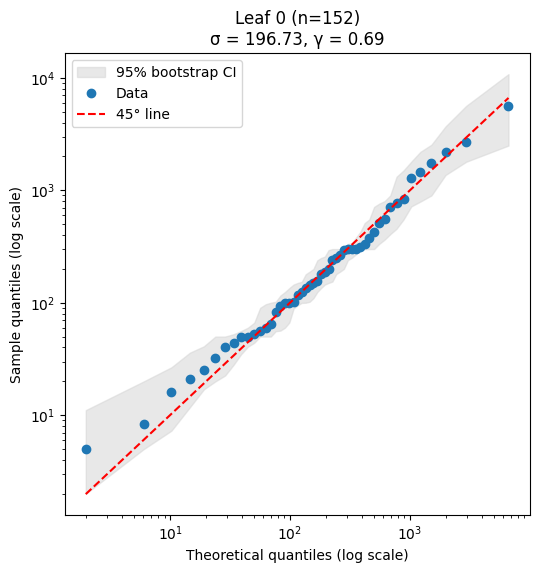

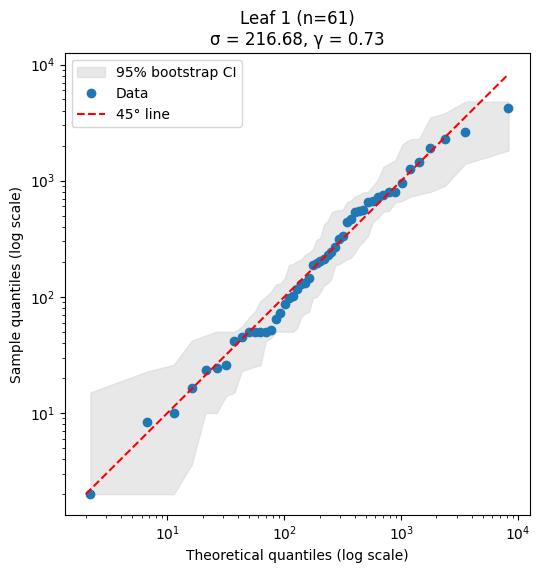

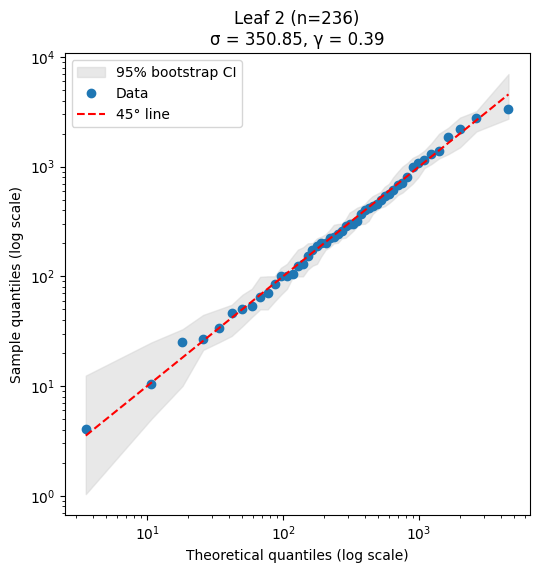

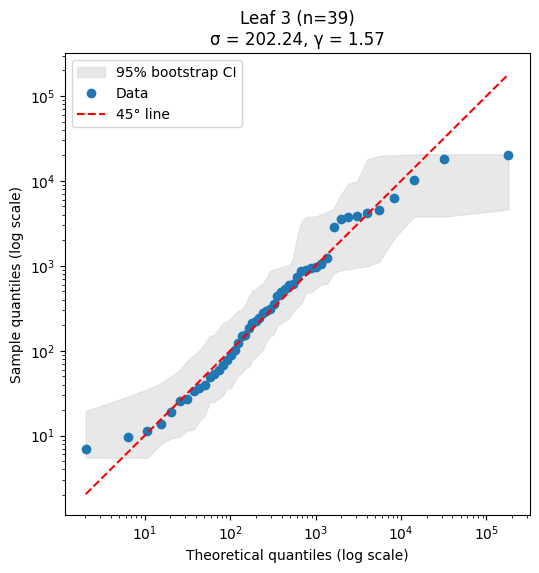

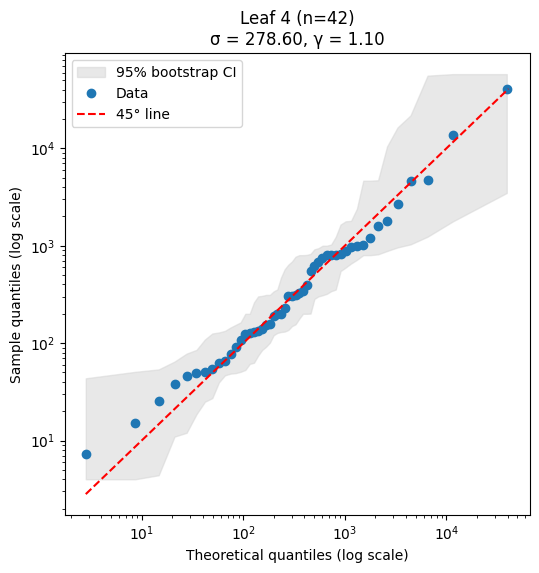

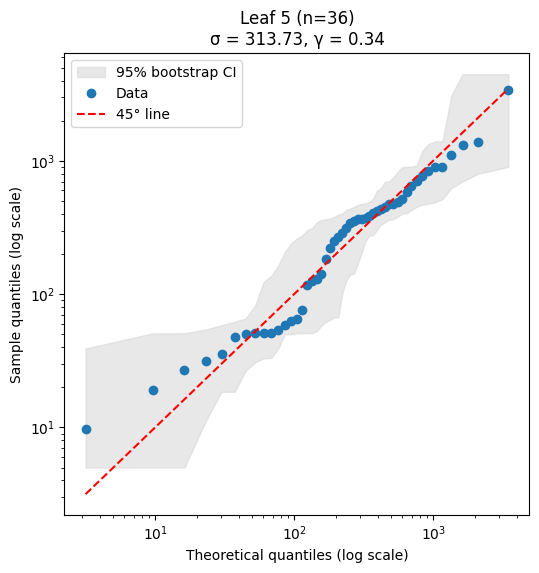

In [74]:
graphs.plot_gp_tree_qq(gpd_tail_tree_pruned, X_tail, y_tail)


In [75]:
import pickle

# --- __main__ 블록 마지막에 추가 ---
save_path = '/content/drive/MyDrive/Operational_risk/'
# 1) 저장할 객체들 모으기
output = {
    # Bulk 트리
    'l1_bulk_tree' : l1_bulk_tree,
    'l2_bulk_tree' : l2_bulk_tree,
    # Tail 트리
    'gpd_raw_tree' : gpd_tail_tree_raw,
    'gpd_pruned_tree' : gpd_tail_tree_pruned,
    # 데이터
    'X_bulk'       : X_bulk,
    'y_bulk'       : y_bulk,
    'X_tail'       : X_tail,
    'y_tail'       : y_tail,
    'X_all_data'   : X_all_data,
    'y_all_data'   : y_all_data,
    'df_model_ready':df_model_ready,
    # (선택) 피처 이름
    'feature_names': feature_names_list,
    # (선택) 임계값
    'u_threshold'  : u_threshold
}

# 2) 피클 파일로 저장
with open(save_path + 'EPU_Non_Finance.pkl', 'wb') as f:
    pickle.dump(output, f)



In [76]:
# ================== POST-FIT EVAL: AIC/BIC, VaR, ES, GOF ==================

# ★ 1) raw y (초과치 아님) 준비
y_tail_raw = y_all_data[mask_tail]        # raw tail values
y_tail_excess = y_tail                    # (이미 있음) excess = y - u_threshold

# ★ 2) 네임스페이스 통일 (patched 모듈 함수 바인딩)
find_leaf_fn  = l1_l2_gpd_patched_new_catprune.find_leaf
get_leaves_fn = l1_l2_gpd_patched_new_catprune._get_all_leaves

# ★ 3) LN-only 트리도 patched 모듈로 생성 + 파라미터 부여
ln_only_tree = l1_l2_gpd_patched_new_catprune.grow_tree_l1(
    X_all_data, y_all_data, feature_names_list, min_leaf=30, max_depth=4
)
l1_l2_gpd_patched_new_catprune.assign_lognorm_params(
    ln_only_tree, X_all_data, y_all_data, trunc_right=None
)

# 4) (선택) Bulk 모델로는 L2 트리 사용한 혼합 ln+gpd 성능을 보고 싶다면
tree_ln_for_mix  = l2_bulk_tree                      # bulk용 LN 트리
tree_gpd_for_mix = gpd_tail_tree_pruned              # tail용 GPD 트리 (없으면 None)

# 5) 모델 로그가능도/정보기준
ll_ln, k_ln, aic_ln, bic_ln = evaluation.model_loglik_aic_bic(
    ln_only_tree, None,
    X_all_data, y_all_data,                      # LN-only: bulk=전체
    np.empty((0, X_all_data.shape[1])), np.empty(0),  # tail 없음
    u_threshold,
    find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
)

if tree_gpd_for_mix is not None:
    ll_mix, k_mix, aic_mix, bic_mix = evaluation.model_loglik_aic_bic(
        tree_ln_for_mix, tree_gpd_for_mix,
        X_bulk, y_bulk,                         # bulk set
        X_tail, y_tail_raw,                     # ★ raw tail 필요!
        u_threshold,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn
    )
else:
    ll_mix, k_mix, aic_mix, bic_mix = (np.nan, np.nan, np.nan, np.nan)

print(f"[LN Only]  logL={ll_ln:.1f}, k={k_ln}, AIC={aic_ln:.1f}, BIC={bic_ln:.1f}")
if tree_gpd_for_mix is not None:
    print(f"[LN+GPD]  logL={ll_mix:.1f}, k={k_mix}, AIC={aic_mix:.1f}, BIC={bic_mix:.1f}")
else:
    print("[LN+GPD]  (tail 표본 부족으로 GPD 트리 없음)")

# 6) VaR / ES
var_ln  = evaluation.unconditional_var_ln(ln_only_tree, get_leaves=get_leaves_fn, alpha=0.99)
es_ln   = evaluation.unconditional_es_ln(ln_only_tree,  get_leaves=get_leaves_fn, alpha=0.99)

if tree_gpd_for_mix is not None:
    var_mix = evaluation.unconditional_var_mix(tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    es_mix  =evaluation.unconditional_es_mix (tree_ln_for_mix, tree_gpd_for_mix, u_threshold,
                                    get_leaves=get_leaves_fn, alpha=0.99)
    print(f"99% VaR | LN Only = {var_ln:,.0f}   LN+GPD = {var_mix:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}   LN+GPD = {es_mix:,.0f}")
else:
    print(f"99% VaR | LN Only = {var_ln:,.0f}")
    print(f"99% ES  | LN Only = {es_ln:,.0f}")

# 7) GPD 리프별 GOF (KS/AD) — excess 필요
if tree_gpd_for_mix is not None:
    gof_df = evaluation.gpd_gof_leafwise(
        tree_gpd_for_mix, X_tail, y_tail_excess,
        find_leaf=find_leaf_fn, get_leaves=get_leaves_fn, method="both"
    )
    pd.set_option('display.float_format', '{:,.3f}'.format)
    print("\n=== GPD Leaf-wise KS / AD Results ===")
    print(gof_df.to_string(index=False))


[LN Only]  logL=-44317.3, k=22, AIC=88678.7, BIC=88839.5
[LN+GPD]  logL=-44301.3, k=34, AIC=88670.5, BIC=88919.0
99% VaR | LN Only = 612   LN+GPD = 535
99% ES  | LN Only = 1,520   LN+GPD = inf

=== GPD Leaf-wise KS / AD Results ===
        leaf_id   n   sigma  gamma  KS stat  KS p  AD stat  AD p
136061390145984 236 350.853  0.393    0.034 0.933    0.252 0.868
136061390150208  42 278.602  1.096    0.066 0.987    0.224 1.000
136061390155968  61 216.678  0.730    0.085 0.733    0.387 0.402
136061390158400  36 313.725  0.338    0.119 0.642    0.448 0.283
136061390159296 152 196.727  0.694    0.063 0.561    0.516 0.193
136061390159680  39 202.237  1.575    0.081 0.942    0.259 0.833


In [77]:
import numpy as np
import pandas as pd
from scipy import stats

# ──────────────────────────────────────────────
# 0) Monte-Carlo 기반 VaR/ES 계산 (ppf 사용 안 함)
# ──────────────────────────────────────────────
def mc_var_es(dist, params, alpha=0.99, n_mc=300_000, random_state=42):
    """
    dist   : scipy.stats 배포( .rvs 가능 )
    params : dist.fit(...) 결과 파라미터 (튜플)
    alpha  : 신뢰수준 (예: 0.99)
    n_mc   : MC 표본 수
    """
    rng = np.random.default_rng(random_state)
    samples = dist.rvs(*params, size=n_mc, random_state=rng)

    # 샘플 기반 VaR/ES
    var_alpha = np.quantile(samples, alpha)
    tail = samples[samples >= var_alpha]
    # tail이 비면 방어적 처리
    if tail.size == 0:
        k = max(1, int(np.ceil(0.001 * n_mc)))
        tail = np.partition(samples, -k)[-k:]
    es_alpha = float(tail.mean())
    return float(var_alpha), es_alpha

# ──────────────────────────────────────────────
# 1) 적합 + AIC/BIC + (MC) VaR + (MC) ES
# ──────────────────────────────────────────────
def fit_score_var_es(dist, data, name,
                     fix_loc0=True,    # NIG에는 False 권장
                     alpha=0.99,
                     n_es_mc=300_000,
                     random_state=42):
    """
    dist, data, name, alpha 동일.
    n_es_mc : ES/ VaR 추정을 위한 MC 표본 수
    """
    try:
        data = np.asarray(data, dtype=float)
        data = data[np.isfinite(data)]
        if data.size == 0:
            raise ValueError("No valid data points.")

        # ① 분포 적합 (MLE)
        if fix_loc0:
            params = dist.fit(data, floc=0)   # loc을 0으로 고정 (NIG에는 비권장)
            k = len(params) - 1
        else:
            params = dist.fit(data)           # loc/scale/shape 모두 추정
            k = len(params)

        # ② 로그 가능도
        logpdf = dist.logpdf(data, *params)
        logpdf = logpdf[np.isfinite(logpdf)]
        logL   = float(logpdf.sum())
        n      = int(data.size)

        # ③ AIC / BIC
        aic = 2*k - 2*logL
        bic = np.log(n)*k - 2*logL

        # ④~⑤ VaR/ES (모두 MC로 계산 → ppf 사용 안 함)
        var_alpha, es_alpha = mc_var_es(dist, params, alpha, n_es_mc, random_state)

        return {
            "Distribution": name,
            "Log-Likelihood": logL,
            "AIC": aic,
            "BIC": bic,
            f"VaR {int(alpha*100)}%": var_alpha,
            f"ES  {int(alpha*100)}%": es_alpha
        }

    except Exception as e:
        return {
            "Distribution": name,
            "Log-Likelihood": f"Fit failed: {e}",
            "AIC": np.nan,
            "BIC": np.nan,
            f"VaR {int(alpha*100)}%": np.nan,
            f"ES  {int(alpha*100)}%": np.nan
        }

# ──────────────────────────────────────────────
# 2) 후보 분포 지정 & 실행
# ──────────────────────────────────────────────
candidates = {
    "Log-Normal":     (stats.lognorm,     True),
    "Gamma":          (stats.gamma,       True),
    "Weibull":        (stats.weibull_min, True),
    # NIG는 scipy.stats.norminvgauss (shape: a, b; loc, scale)
    # ★ floc=0 고정하지 마세요 → 수치 불안정 완화
    "NIG":            (stats.norminvgauss, False),
}

alpha = 0.99
results = [fit_score_var_es(dist, y_all_data, name,
                            fix_loc0=fix_loc0,   # NIG는 False
                            alpha=alpha,
                            n_es_mc=300_000,
                            random_state=42)
           for name, (dist, fix_loc0) in candidates.items()]

results_df = (pd.DataFrame(results)
                .sort_values("AIC", key=lambda s: s.fillna(np.inf))
                .reset_index(drop=True))

print(results_df)


  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%
0   Log-Normal     -44,713.375 89,430.750 89,445.366   563.164 1,455.507
1          NIG     -44,880.481 89,768.962 89,798.193 1,418.331 3,321.771
2      Weibull     -46,427.496 92,858.991 92,873.607   452.938   695.737
3        Gamma     -48,980.747 97,965.494 97,980.110   593.468   783.577



================  Model Comparison  ================

  Distribution  Log-Likelihood        AIC        BIC   VaR 99%   ES  99%  \
0       LN+GPD     -44,301.252 88,670.505 88,918.971   535.422       inf   
1   Log-Normal     -44,713.375 89,430.750 89,445.366   563.164 1,455.507   
2          NIG     -44,880.481 89,768.962 89,798.193 1,418.331 3,321.771   
3      Weibull     -46,427.496 92,858.991 92,873.607   452.938   695.737   
4        Gamma     -48,980.747 97,965.494 97,980.110   593.468   783.577   

       k  
0 34.000  
1    NaN  
2    NaN  
3    NaN  
4    NaN  


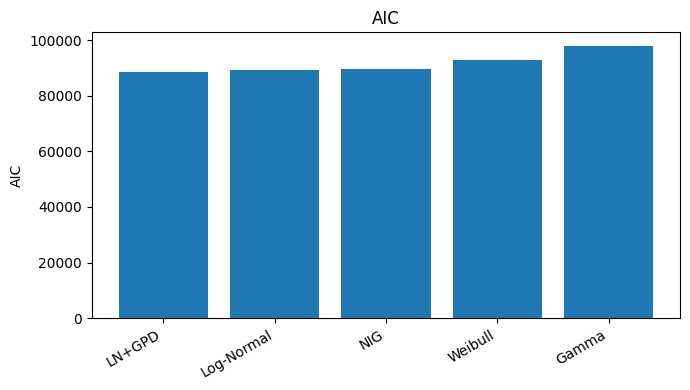

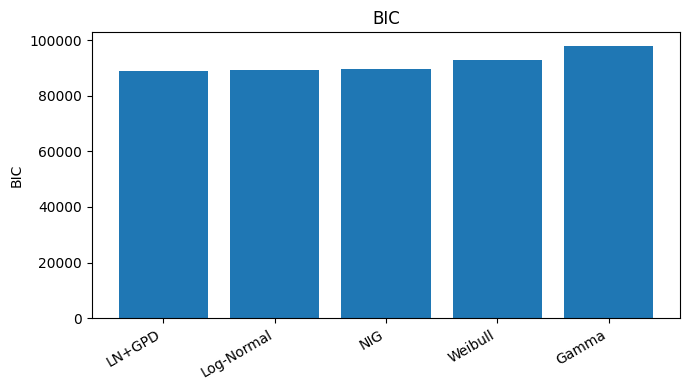

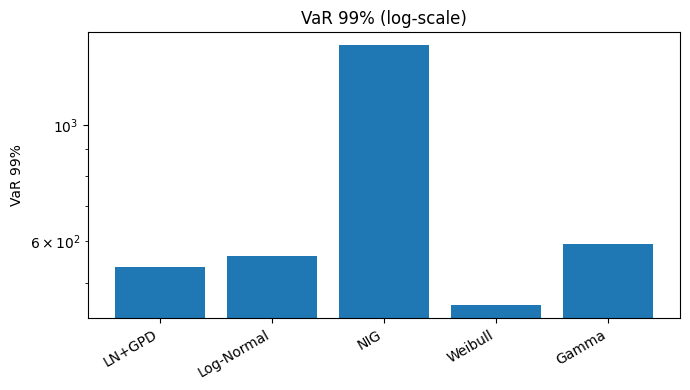

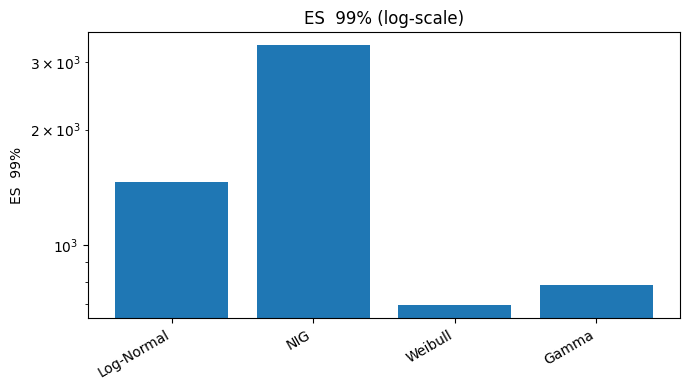

In [78]:
# ──────────────────────────────────────────────
# 0) Tree 모델 행을 만들어 results_df 와 합치기
# ──────────────────────────────────────────────
tree_rows = pd.DataFrame([
#    {"Distribution": "LN‑Tree",  "Log-Likelihood": ll_ln,  "k": k_ln,
#     "AIC": aic_ln,  "BIC": bic_ln,
 #    "VaR 99%": var_ln,  "ES  99%": es_ln},
    {"Distribution": "LN+GPD",   "Log-Likelihood": ll_mix, "k": k_mix,
     "AIC": aic_mix, "BIC": bic_mix,
     "VaR 99%": var_mix, "ES  99%": es_mix}
])

full_df = (pd.concat([results_df, tree_rows], ignore_index=True)
             .sort_values("AIC")
             .reset_index(drop=True))

print("\n================  Model Comparison  ================\n")
print(full_df)

# ──────────────────────────────────────────────
# 1) AIC / BIC   (로그축 X)
# ──────────────────────────────────────────────
import matplotlib.pyplot as plt

for metric in ["AIC", "BIC"]:
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], full_df[metric])
    plt.title(f"{metric}")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()

# ──────────────────────────────────────────────
# 2) VaR / ES   (log‑scale로 값 차이를 보기 좋게)
# ──────────────────────────────────────────────
for metric in ["VaR 99%", "ES  99%"]:
    y = pd.to_numeric(full_df[metric], errors="coerce").to_numpy(dtype=float)
    y_plot = np.where(np.isfinite(y) & (y > 0), y, np.nan)  # 🔧 inf/<=0 → NaN
    plt.figure(figsize=(7,4))
    plt.bar(full_df["Distribution"], y_plot)
    plt.yscale("log")
    plt.title(f"{metric} (log-scale)")
    plt.xticks(rotation=30, ha="right")
    plt.ylabel(metric)
    plt.tight_layout()
    plt.show()





#END